<a href="https://colab.research.google.com/github/melissanespeque/statisticsfinalproject/blob/main/p06_statistics_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ASPA Project: P06 – Arrhenius or super-Arrhenius relaxation time of glasses**

## Libraries

In [1]:
# Libraries import

if (!requireNamespace("rstan", quietly = TRUE)) {
  install.packages("rstan", repos = "https://cloud.r-project.org/", dependencies = TRUE)
}
if (!requireNamespace("loo", quietly = TRUE)) {
  install.packages("loo", repos = "https://cloud.r-project.org/")
}
if (!requireNamespace("bayesplot", quietly = TRUE)) {
  install.packages("bayesplot", repos = "https://cloud.r-project.org/")
}
if (!requireNamespace("moments", quietly = TRUE)) install.packages("moments")
if (!requireNamespace("patchwork", quietly = TRUE)) install.packages("patchwork")

library(rstan)
library(loo)
library(ggplot2)
library(bayesplot)
library(moments)
library(patchwork)

options(mc.cores = parallel::detectCores())
rstan_options(auto_write = TRUE)

SEED <- 123

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘numDeriv’, ‘lazyeval’, ‘abind’, ‘tensorA’, ‘distributional’, ‘crosstalk’, ‘zoo’, ‘litedown’, ‘plyr’, ‘igraph’, ‘checkmate’, ‘matrixStats’, ‘posterior’, ‘colourpicker’, ‘DT’, ‘dygraphs’, ‘gtools’, ‘markdown’, ‘reshape2’, ‘shinyjs’, ‘shinythemes’, ‘threejs’, ‘xts’, ‘ggridges’, ‘StanHeaders’, ‘inline’, ‘gridExtra’, ‘RcppParallel’, ‘loo’, ‘QuickJSR’, ‘RcppEigen’, ‘BH’, ‘shinystan’, ‘bayesplot’, ‘rstantools’, ‘coda’, ‘V8’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(a

In [2]:
# Global color palette (Okabe-Ito, colorblind-safe) and plot theme
pal_okabe_ito <- c("Metropolis" = "#0072B2", "kSwap" = "#D55E00")

theme_glass <- function(base_size = 13) {
  theme_bw(base_size = base_size) +
    theme(
      panel.grid.minor = element_blank(),
      panel.grid.major = element_line(color = "grey90", linewidth = 0.3),
      panel.border = element_rect(color = "black", linewidth = 0.6, fill = NA),
      axis.title = element_text(face = "bold"),
      axis.text = element_text(color = "black"),
      legend.title = element_blank(),
      legend.background = element_rect(fill = "white", color = "black", linewidth = 0.3),
      legend.key = element_blank(),
      strip.background = element_rect(fill = "grey95", color = "black"),
      strip.text = element_text(face = "bold"),
      plot.title = element_text(face = "bold", size = base_size + 1)
    )
}
theme_set(theme_glass())

## Initial Data Reading

In [3]:
#File import and data reading

lines <- readLines("3d_Relaxation_Time.csv")
block_index <- grep("Algorithm =", lines)

data_algorithms <- list()

for (i in seq_along(block_index)) {
  idx_meta <- block_index[i]
  idx_data_start <- idx_meta + 2
  idx_data_end <- if (i < length(block_index)) block_index[i + 1] - 2 else length(lines)

  lines_meta <- lines[idx_meta]
  name_algorithm <- gsub('.*Algorithm = "(.*?)".*', '\\1', lines_meta)

  text_block <- lines[idx_data_start:idx_data_end]
  text_block <- text_block[nzchar(trimws(text_block))]  # remove residual empty lines

  df_clean <- read.table(text = text_block, sep = ",", header = FALSE,
                          strip.white = TRUE)
  colnames(df_clean) <- c("N", "rho", "temperature", "relaxation_time", "error")

  data_algorithms[[name_algorithm]] <- df_clean
}

df_metropolis <- data_algorithms[["Metropolis"]]
df_kswap      <- data_algorithms[["k_max = 100 kSwap"]]

Warning message in readLines("3d_Relaxation_Time.csv"):
“incomplete final line found on '3d_Relaxation_Time.csv'”


In [4]:
df_metropolis

N,rho,temperature,relaxation_time,error
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1024,1,0.10,229458.4771,11112.692783
1024,1,0.12,6441.2940,222.266268
1024,1,0.13,2771.1542,63.828816
1024,1,0.14,1482.4511,33.451623
1024,1,0.15,915.6720,18.802833
1024,1,0.16,657.7929,12.159564
1024,1,0.17,503.8613,7.802433
1024,1,0.18,406.2602,7.038857
1024,1,0.19,332.2591,4.580939


In [5]:
df_kswap

N,rho,temperature,relaxation_time,error
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1024,1,0.06,49220.34988,1308.6315613
1024,1,0.08,3602.85563,55.0351922
1024,1,0.10,1237.01819,15.7839638
1024,1,0.12,603.89854,7.5533883
1024,1,0.13,481.64759,4.4758795
1024,1,0.14,381.14608,2.9206710
1024,1,0.15,329.36600,2.8928262
1024,1,0.16,281.27953,2.3296362
1024,1,0.17,249.03782,1.9183449


### Exploratory Data Analysis

--- Summary Metropolis ---


  temperature     relaxation_time        error          
 Min.   :0.1000   Min.   :   110.9   Min.   :    1.072  
 1st Qu.:0.1450   1st Qu.:   205.3   1st Qu.:    2.020  
 Median :0.1800   Median :   406.3   Median :    7.039  
 Mean   :0.1853   Mean   : 16274.3   Mean   :  766.214  
 3rd Qu.:0.2250   3rd Qu.:  1199.1   3rd Qu.:   26.127  
 Max.   :0.3000   Max.   :229458.5   Max.   :11112.693  


--- Summary K-Swap ---


  temperature     relaxation_time        error          
 Min.   :0.0600   Min.   :   96.37   Min.   :   0.6264  
 1st Qu.:0.1300   1st Qu.:  155.89   1st Qu.:   0.9747  
 Median :0.1700   Median :  249.04   Median :   1.9183  
 Mean   :0.1718   Mean   : 3391.41   Mean   :  82.9640  
 3rd Qu.:0.2200   3rd Qu.:  481.65   3rd Qu.:   4.4759  
 Max.   :0.3000   Max.   :49220.35   Max.   :1308.6316  

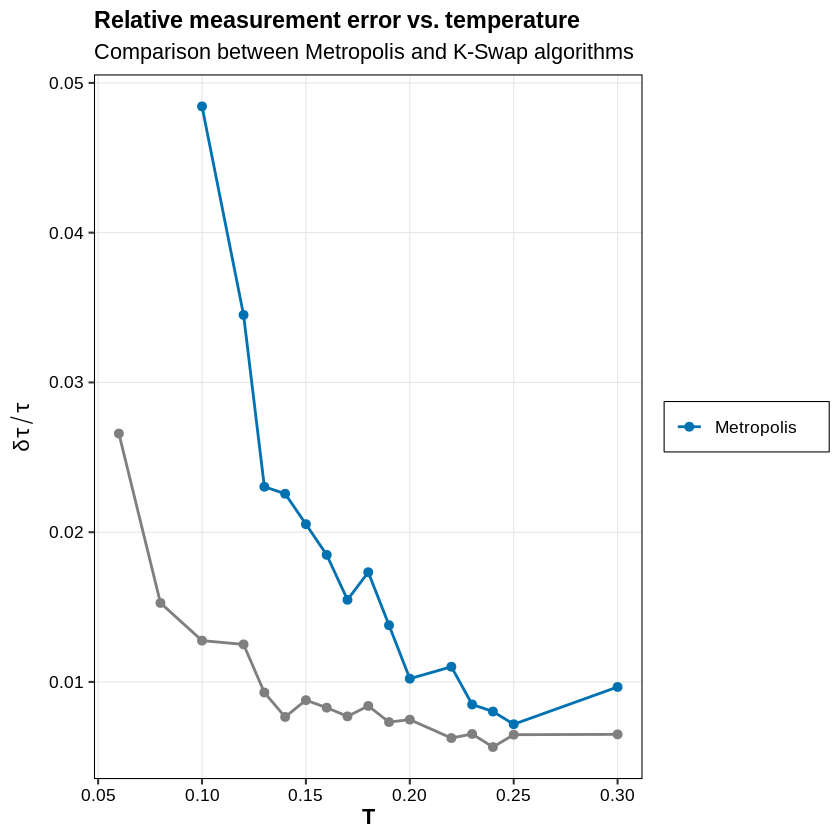

In [6]:
# Simple descriptive statistics for the raw datasets
cat("--- Summary Metropolis ---\n")
summary(df_metropolis[, c("temperature", "relaxation_time", "error")])

cat("\n--- Summary K-Swap ---\n")
summary(df_kswap[, c("temperature", "relaxation_time", "error")])

# Relative error per point
df_metropolis$rel_error <- df_metropolis$error / df_metropolis$relaxation_time
df_metropolis$Algorithm    <- "Metropolis"

df_kswap$rel_error      <- df_kswap$error / df_kswap$relaxation_time
df_kswap$Algorithm        <- "K-Swap"

columns_tbu <- c("temperature", "rel_error", "Algorithm")
df_combined <- rbind(df_metropolis[, columns_tbu],
                      df_kswap[, columns_tbu])

ggplot(df_combined, aes(x = temperature, y = rel_error, color = Algorithm, group = Algorithm)) +
  geom_point(size = 2) +
  geom_line(linewidth = 0.8) +
  scale_color_manual(values = pal_okabe_ito) +
  labs(
    x = "T",
    y = expression(delta*tau/tau),
    title = "Relative measurement error vs. temperature",
    subtitle = "Comparison between Metropolis and K-Swap algorithms"
  )
      ggsave("relativemeasurement.png", width = 8, height = 6, dpi = 300)

In [16]:
prepare_data <- function(df) {
  df$x <- 1 / df$temperature
  df$y <- log(df$relaxation_time)
  df$sigma_y <- df$error / df$relaxation_time   # delta method: sigma_y = sigma_tau / tau
  df <- na.omit(df)
  return(df)
}

df_metropolis <- prepare_data(df_metropolis)
df_kswap      <- prepare_data(df_kswap)

In [17]:
df_metropolis

N,rho,temperature,relaxation_time,error,rel_error,Algorithm,x,y,sigma_y
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1024,1,0.10,229458.4771,11112.692783,0.048430082,Metropolis,10.000000,12.343477,0.048430082
1024,1,0.12,6441.2940,222.266268,0.034506462,Metropolis,8.333333,8.770485,0.034506462
1024,1,0.13,2771.1542,63.828816,0.023033297,Metropolis,7.692308,7.927019,0.023033297
1024,1,0.14,1482.4511,33.451623,0.022565077,Metropolis,7.142857,7.301452,0.022565077
1024,1,0.15,915.6720,18.802833,0.020534463,Metropolis,6.666667,6.819658,0.020534463
1024,1,0.16,657.7929,12.159564,0.018485397,Metropolis,6.250000,6.488890,0.018485397
1024,1,0.17,503.8613,7.802433,0.015485277,Metropolis,5.882353,6.222301,0.015485277
1024,1,0.18,406.2602,7.038857,0.017325982,Metropolis,5.555556,6.006994,0.017325982
1024,1,0.19,332.2591,4.580939,0.013787250,Metropolis,5.263158,5.805915,0.013787250


In [18]:
  df_kswap

N,rho,temperature,relaxation_time,error,rel_error,Algorithm,x,y,sigma_y
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
1024,1,0.06,49220.34988,1308.6315613,0.026587206,kSwap,16.666667,10.804062,0.026587206
1024,1,0.08,3602.85563,55.0351922,0.015275436,kSwap,12.500000,8.189482,0.015275436
1024,1,0.10,1237.01819,15.7839638,0.012759686,kSwap,10.000000,7.120459,0.012759686
1024,1,0.12,603.89854,7.5533883,0.012507711,kSwap,8.333333,6.403406,0.012507711
1024,1,0.13,481.64759,4.4758795,0.009292851,kSwap,7.692308,6.177213,0.009292851
1024,1,0.14,381.14608,2.9206710,0.007662865,kSwap,7.142857,5.943183,0.007662865
1024,1,0.15,329.36600,2.8928262,0.008783014,kSwap,6.666667,5.797170,0.008783014
1024,1,0.16,281.27953,2.3296362,0.008282282,kSwap,6.250000,5.639349,0.008282282
1024,1,0.17,249.03782,1.9183449,0.007703026,kSwap,5.882353,5.517605,0.007703026


## Log(tau) X 1/T

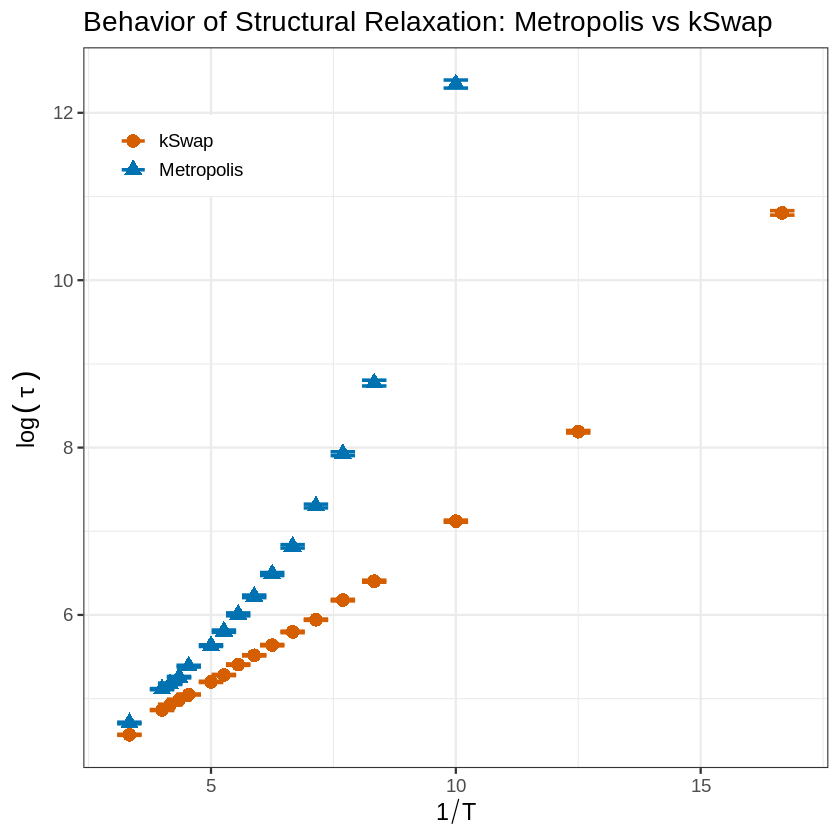

In [19]:
df_metropolis$Algorithm <- "Metropolis"
df_kswap$Algorithm      <- "kSwap"

df_plot <- rbind(
  df_metropolis[, c("x", "y", "sigma_y", "Algorithm")],
  df_kswap[, c("x", "y", "sigma_y", "Algorithm")]
)

#Behavior of Structural Relaxation: Metropolis vs kSwap"
ggplot(df_plot, aes(x = x, y = y, color = Algorithm, shape = Algorithm)) +
  geom_errorbar(aes(ymin = y - sigma_y, ymax = y + sigma_y), width = 0.5, linewidth = 1.0) +
  geom_point(size = 3.2, stroke = 1) +
  scale_color_manual(values = c("Metropolis" = "#0072B2", "kSwap" = "#D55E00")) +
  labs(x = expression(1 / T), y = expression(log(tau)), title = "Behavior of Structural Relaxation: Metropolis vs kSwap") +
  theme_bw(base_size = 14) +
  theme(legend.position = c(0.15, 0.85), legend.title = element_blank())
  ggsave("behavrelax.png", width = 8, height = 6, dpi = 300)

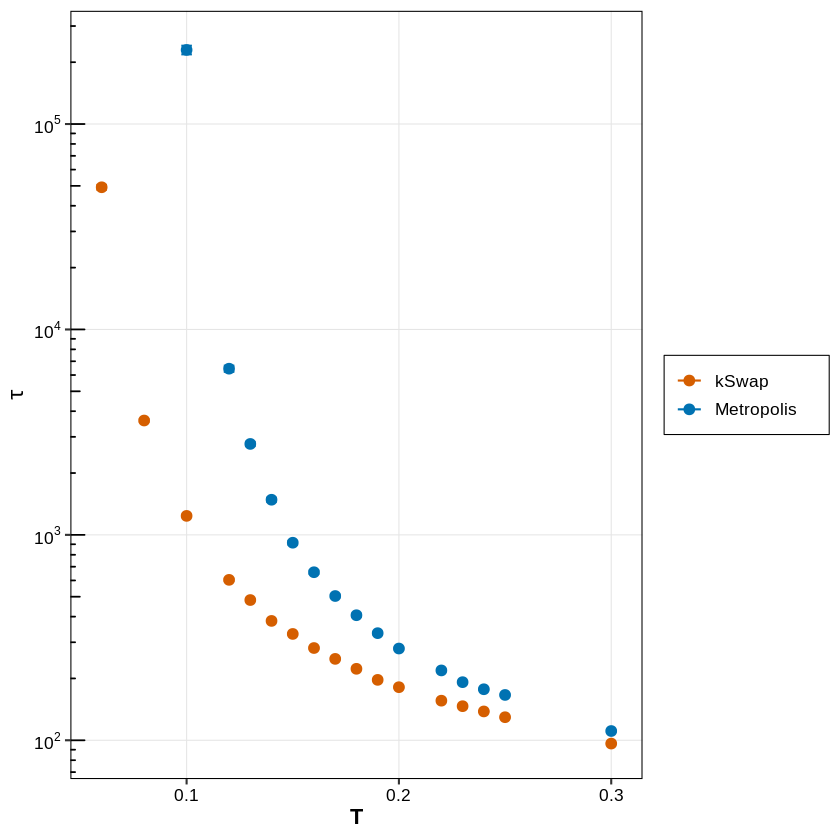

In [20]:


df_tau <- rbind(
  df_metropolis[, c("temperature", "relaxation_time", "error", "Algorithm")],
  df_kswap[, c("temperature", "relaxation_time", "error", "Algorithm")]
)

pal_okabe_ito <- c("Metropolis" = "#0072B2", "kSwap" = "#D55E00")

ggplot(df_tau, aes(x = temperature, y = relaxation_time, color = Algorithm)) +
  geom_errorbar(aes(ymin = relaxation_time - error, ymax = relaxation_time + error),
                width = 0.005) +
  geom_point(size = 2.5) +
  scale_color_manual(values = pal_okabe_ito) +
  scale_y_log10(labels = scales::trans_format("log10", scales::math_format(10^.x))) +
  labs(x = "T", y = expression(tau), color = "Algorithm") +
  annotation_logticks(sides = "l") +
  theme_glass()
ggsave("behavrelaxlog.png", width = 8, height = 6, dpi = 300)

## Stan models

In [21]:
stan_data_metropolis <- list(
  N = nrow(df_metropolis),
  x = df_metropolis$x,
  y = df_metropolis$y,
  sigma_y = df_metropolis$sigma_y
)

### Arrhenius

In [22]:
arrhenius_code <- "
data {
  int<lower=1> N;
  vector[N] x;
  vector[N] y;
  vector[N] sigma_y;
}
parameters {
  real A;
  real<lower=0> E;
  real<lower=0> sigma_int;
}
model {
  A ~ normal(0, 10);
  E ~ normal(0, 20);
  sigma_int ~ cauchy(0, 2);
  for (i in 1:N) {
    real sigma_total = sqrt(square(sigma_y[i]) + square(sigma_int));
    y[i] ~ normal(A + E * x[i], sigma_total);
  }
}
generated quantities {
  vector[N] log_lik;
  vector[N] y_rep;
  for (i in 1:N) {
    real sigma_total = sqrt(square(sigma_y[i]) + square(sigma_int));
    real mu = A + E * x[i];
    log_lik[i] = normal_lpdf(y[i] | mu, sigma_total);
    y_rep[i]   = normal_rng(mu, sigma_total);
  }
}
"
mod_arrhenius <- stan_model(model_code = arrhenius_code)

### VFT

In [23]:
vft_code <- "
data {
  int<lower=1> N;
  vector[N] temp;
  vector[N] y;
  vector[N] sigma_y;
  real min_temp;
}
parameters {
  real A;
  real<lower=0> B;
  real<lower=0, upper=min_temp> T0;
  real<lower=0> sigma_int;
}
model {
  A ~ normal(0, 10);
  B ~ normal(0, 10);
  T0 ~ uniform(0, min_temp);
  sigma_int ~ cauchy(0, 2);
  for (i in 1:N) {
    real sigma_total = sqrt(square(sigma_y[i]) + square(sigma_int));
    y[i] ~ normal(A + B / (temp[i] - T0), sigma_total);
  }
}
generated quantities {
  vector[N] log_lik;
  vector[N] y_rep;
  for (i in 1:N) {
    real sigma_total = sqrt(square(sigma_y[i]) + square(sigma_int));
    real mu = A + B / (temp[i] - T0);
    log_lik[i] = normal_lpdf(y[i] | mu, sigma_total);
    y_rep[i]   = normal_rng(mu, sigma_total);
  }
}
"
mod_vft <- stan_model(model_code = vft_code)

### Running the 4 fits - 2 models x 2 dynamics

In [24]:
chains <- 4
iter <- 2000
warmup <- 1000

# --- Metropolis ---
stan_data_arrh_metropolis <- list(
  N = nrow(df_metropolis),
  x = df_metropolis$x,
  y = df_metropolis$y,
  sigma_y = df_metropolis$sigma_y
)

stan_data_vft_metropolis <- list(
  N = nrow(df_metropolis),
  temp = df_metropolis$temperature,
  y = df_metropolis$y,
  sigma_y = df_metropolis$sigma_y,
  min_temp = min(df_metropolis$temperature)
)

cat("Sampling Metropolis - Arrhenius...\n")
fit_arr_metropolis <- sampling(mod_arrhenius, data = stan_data_arrh_metropolis,
                                chains = chains, iter = iter, warmup = warmup, seed = SEED)

cat("Sampling Metropolis - VFT...\n")
fit_vft_metropolis <- sampling(mod_vft, data = stan_data_vft_metropolis,
                                chains = chains, iter = iter, warmup = warmup, seed = SEED)

# --- K-Swap ---
stan_data_arrh_kswap <- list(
  N = nrow(df_kswap),
  x = df_kswap$x,
  y = df_kswap$y,
  sigma_y = df_kswap$sigma_y
)

stan_data_vft_kswap <- list(
  N = nrow(df_kswap),
  temp = df_kswap$temperature,
  y = df_kswap$y,
  sigma_y = df_kswap$sigma_y,
  min_temp = min(df_kswap$temperature)
)

cat("Sampling K-Swap - Arrhenius...\n")
fit_arr_kswap <- sampling(mod_arrhenius, data = stan_data_arrh_kswap,
                           chains = chains, iter = iter, warmup = warmup, seed = SEED)

cat("Sampling K-Swap - VFT...\n")
fit_vft_kswap <- sampling(mod_vft, data = stan_data_vft_kswap,
                           chains = chains, iter = iter, warmup = warmup, seed = SEED)

Sampling Metropolis - Arrhenius...

ampling Metropolis - VFT...
el' NOW (CHAIN 4).
Chain 4: 
Chain 4: Gradient evaluation took 3.6e-05 seconds
Chain 4: 1000 transitions using 10 leapfrog steps per transition would take 0.36 seconds.
Chain 4: Adjust your expectations accordingly!
Chain 4: 
Chain 4: 
Chain 4: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 3: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 3: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 4: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 3: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 3: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 4: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 3: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 3: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 4: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 3: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 3: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 3: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 4: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 

## Diagnostics and Posterior Analysis


--- Summary for: Metropolis Arrhenius ---
Inference for Stan model: anon_model.
4 chains, each with iter=2000; warmup=1000; thin=1; 
post-warmup draws per chain=1000, total post-warmup draws=4000.

          mean se_mean   sd  2.5%  25%  50%  75% 97.5% n_eff Rhat
A         0.66    0.02 0.61 -0.50 0.23 0.63 1.07  1.86  1332    1
E         1.01    0.00 0.10  0.81 0.94 1.01 1.08  1.20  1339    1
sigma_int 0.67    0.00 0.15  0.45 0.56 0.64 0.74  1.02  1602    1

Samples were drawn using NUTS(diag_e) at Fri Jul  3 07:58:29 2026.
For each parameter, n_eff is a crude measure of effective sample size,
and Rhat is the potential scale reduction factor on split chains (at 
convergence, Rhat=1).

--- HMC Diagnostics: Metropolis Arrhenius ---

Divergences:


0 of 4000 iterations ended with a divergence.




Tree depth:


0 of 4000 iterations saturated the maximum tree depth of 10.




Energy:


...

0 of 4000 iterations ended with a divergence.




Tree depth:


0 of 4000 iterations saturated the maximum tree depth of 10.




Energy:


E-BFMI indicated no pathological behavior.



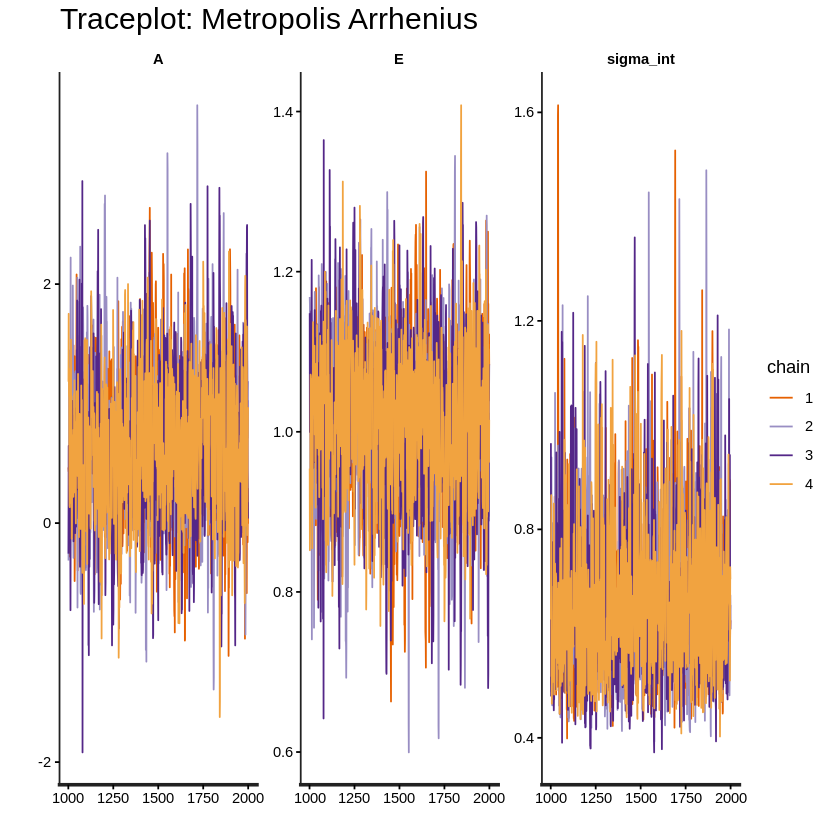

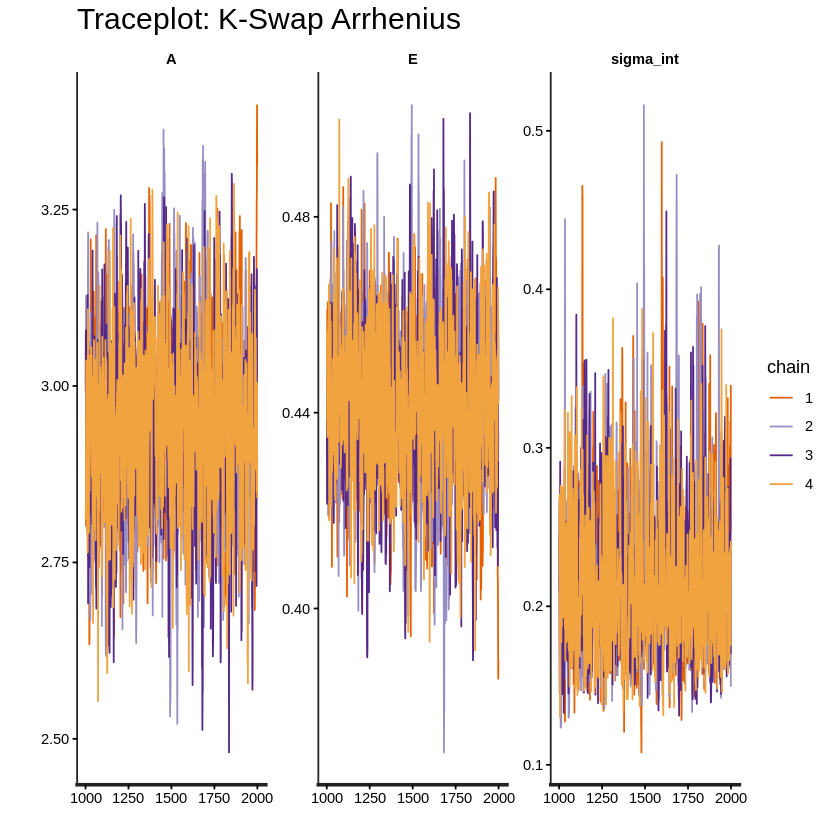

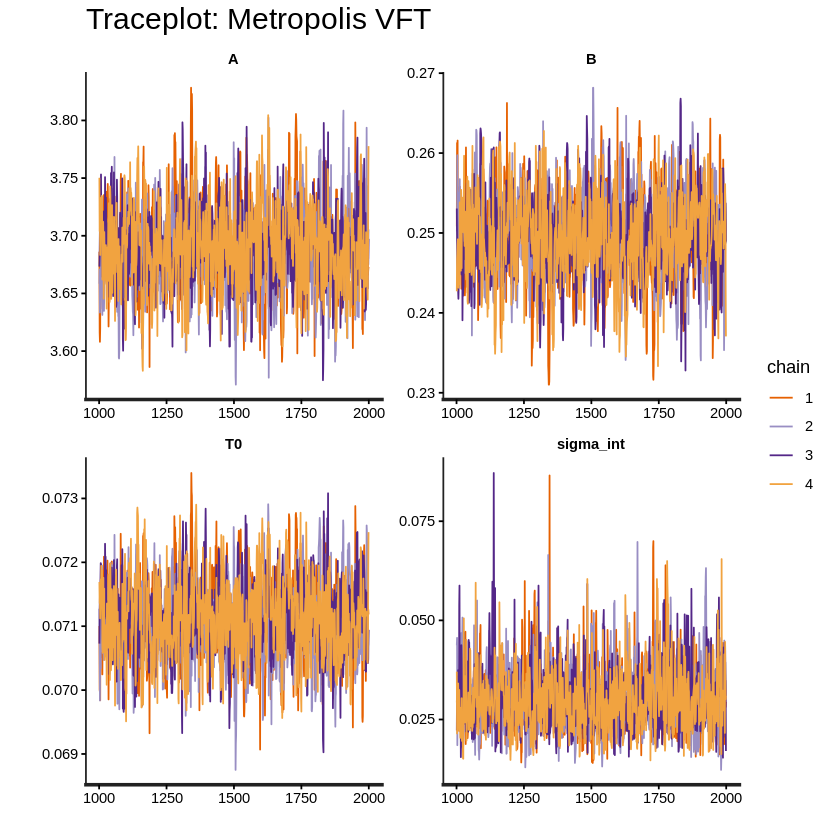

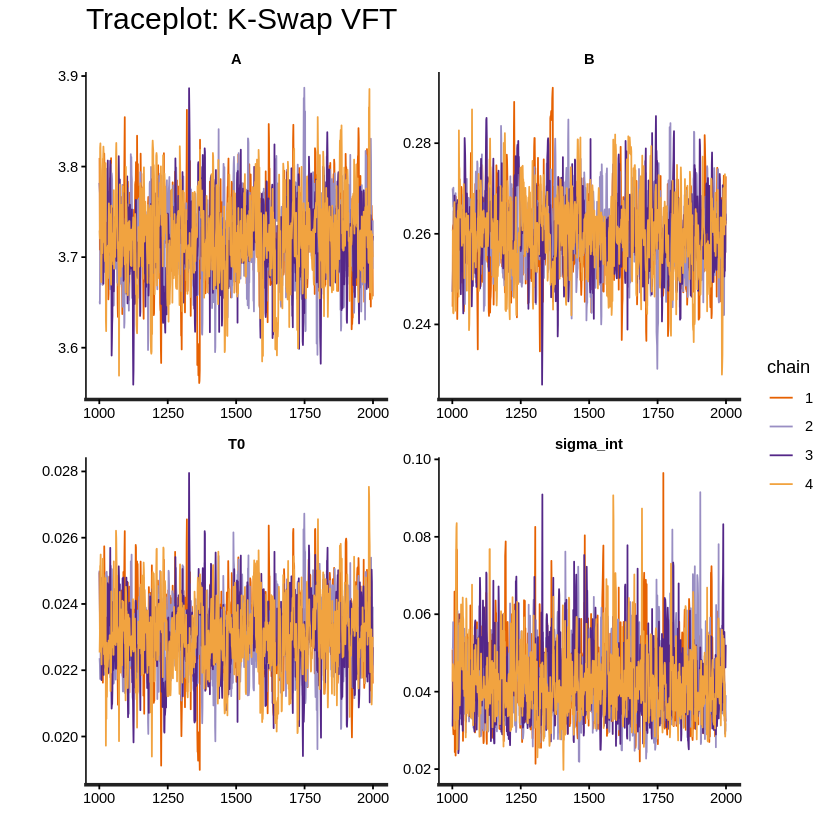

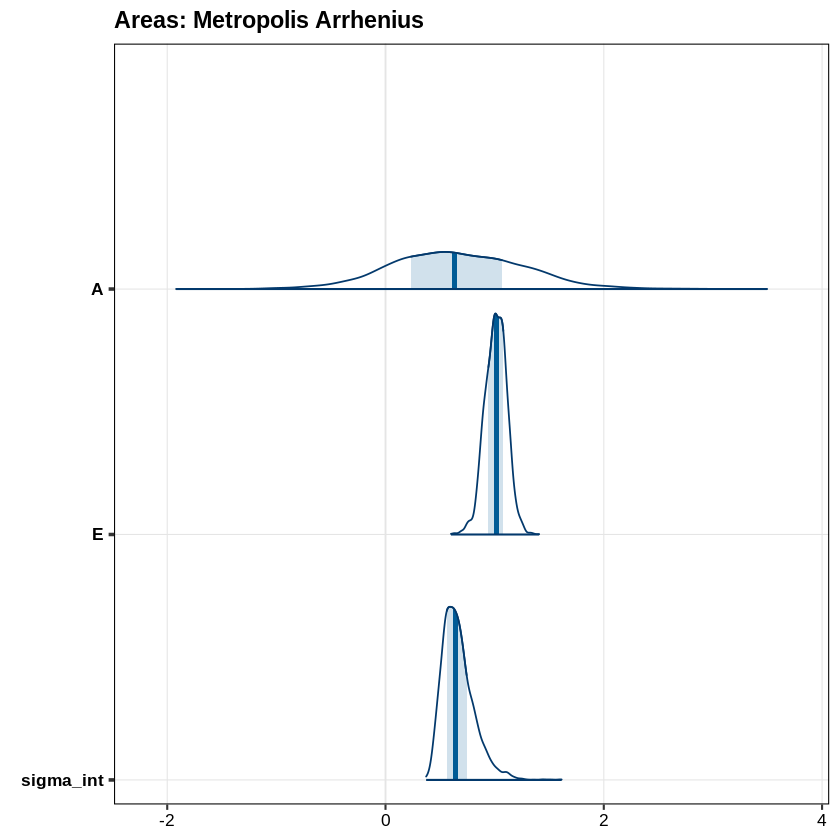

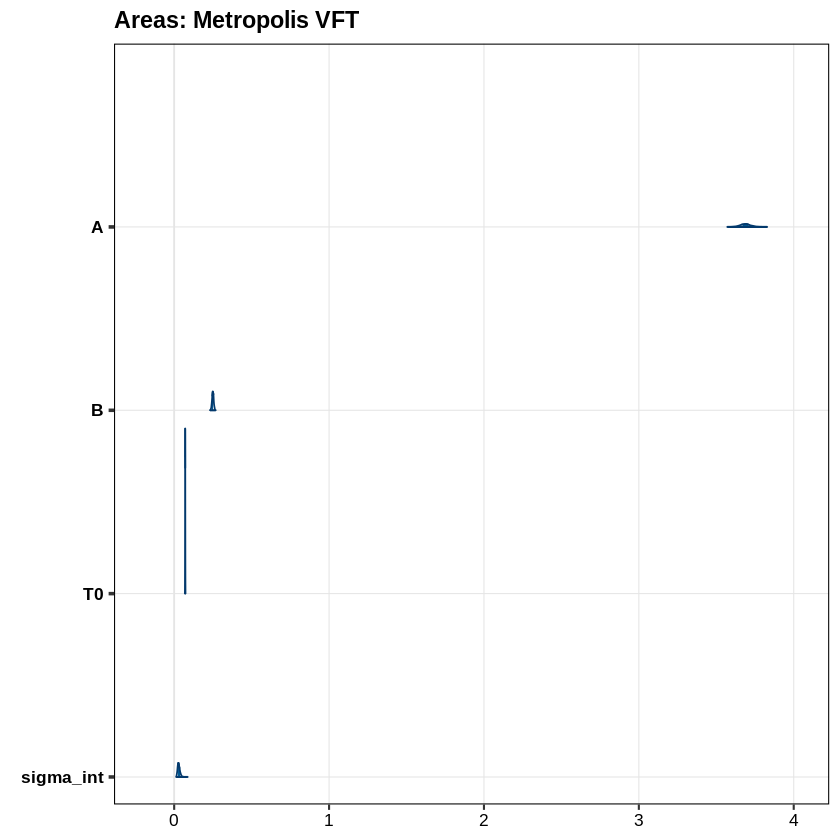

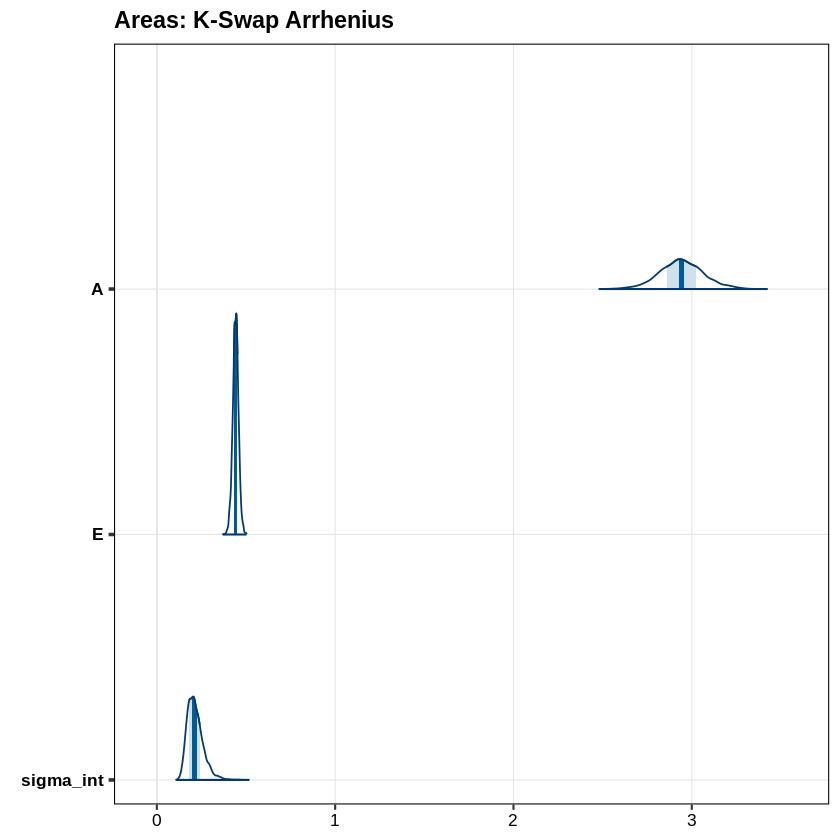

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


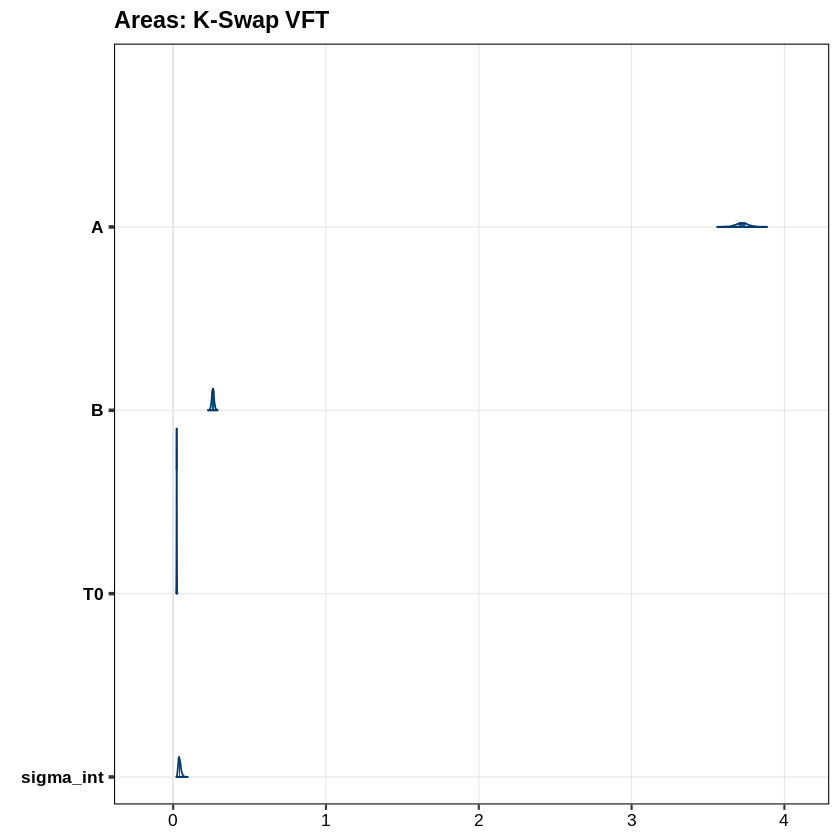

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


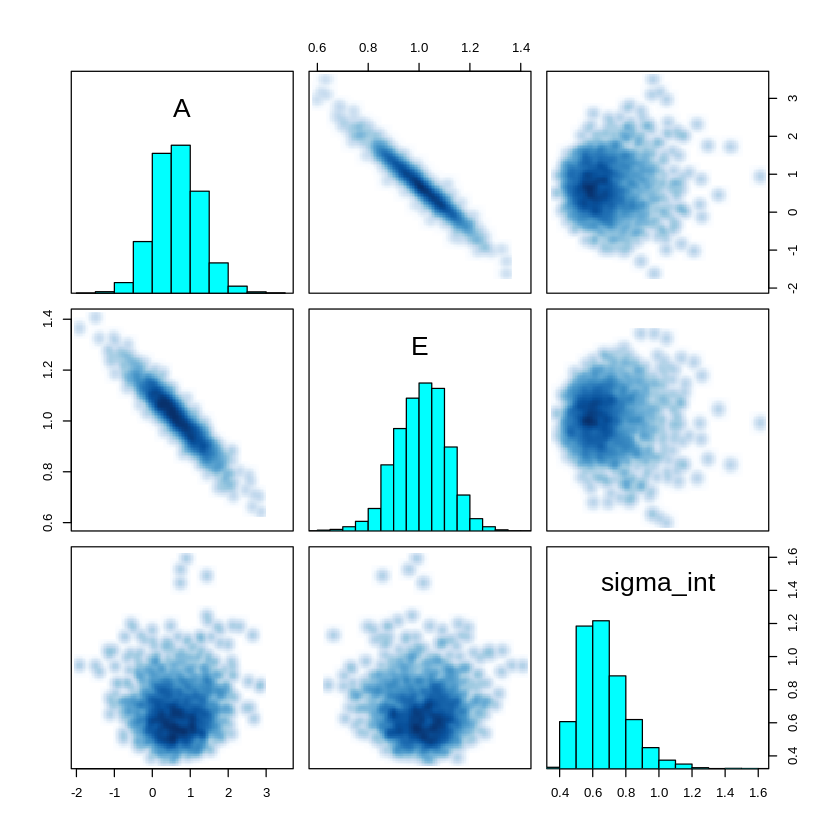

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


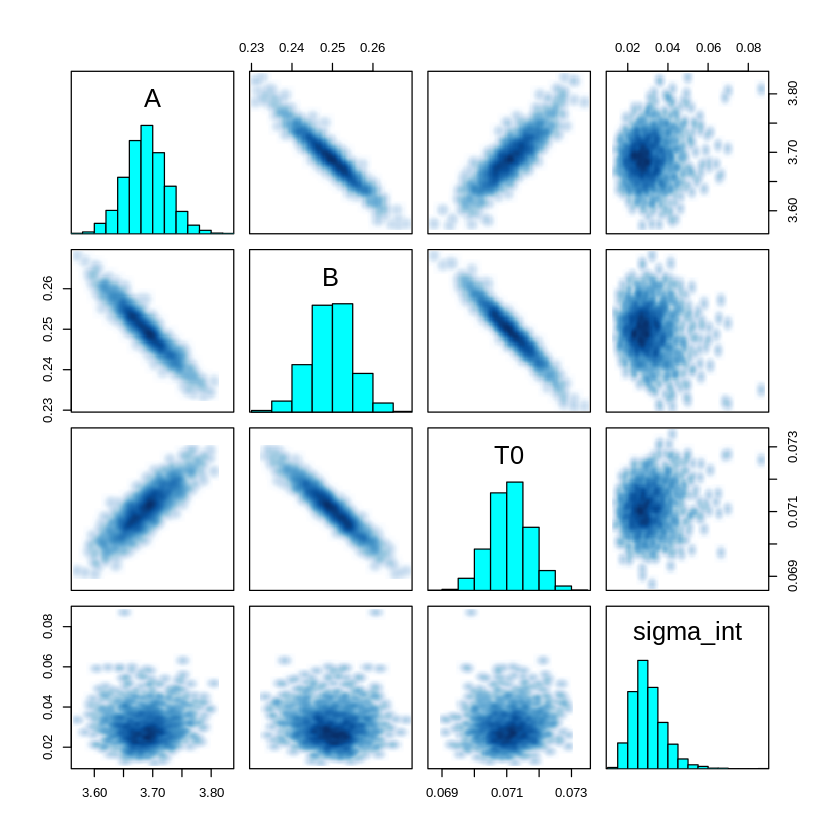

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


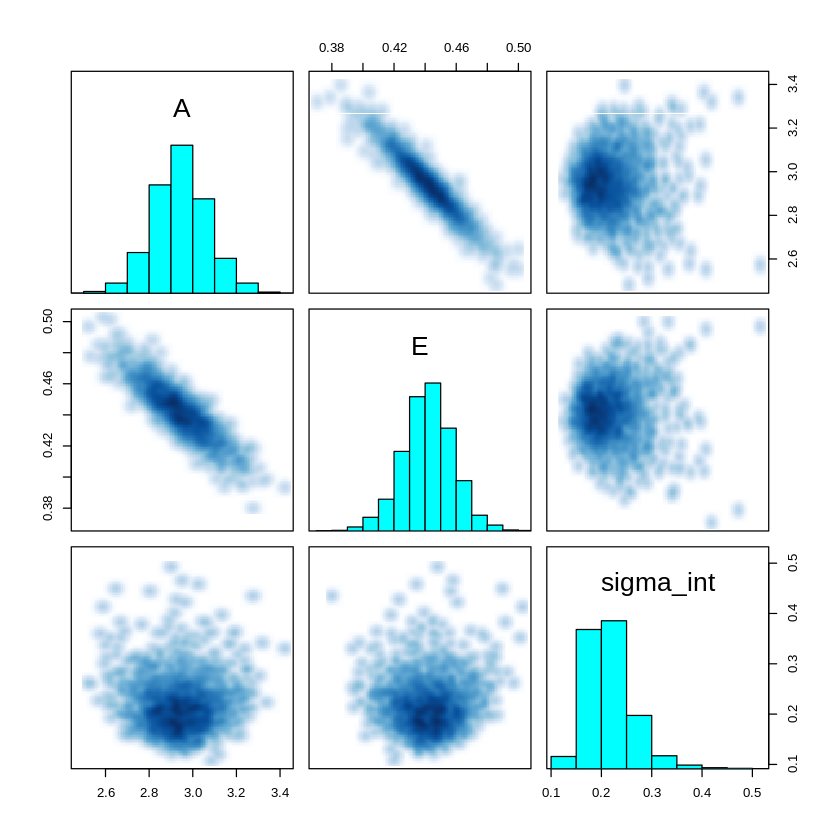

Warning message in par(usr):
“argument 1 does not name a graphical parameter”


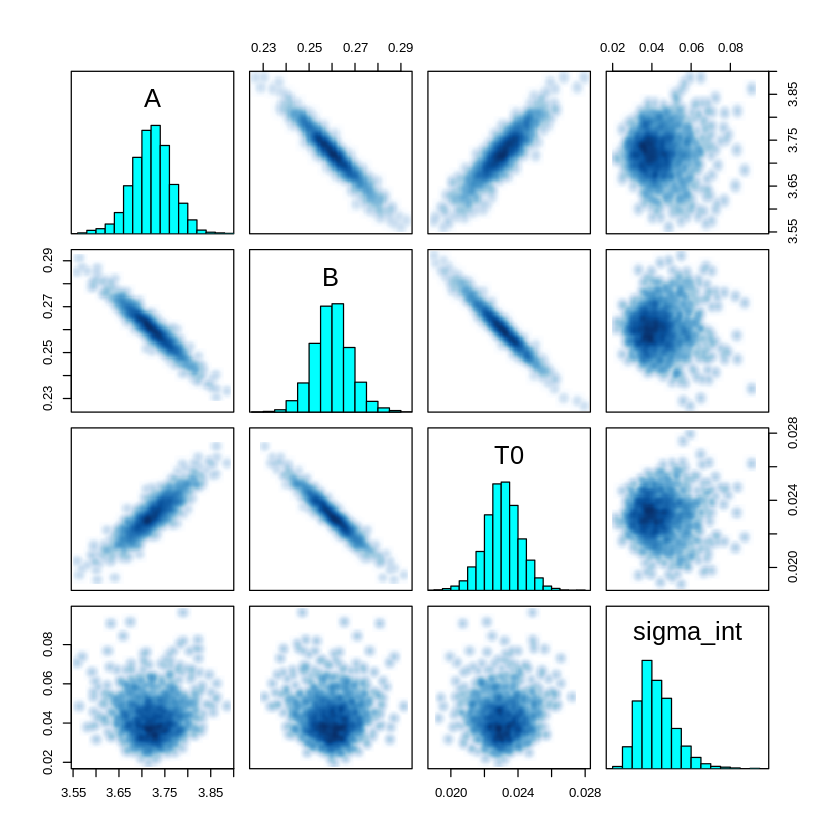

In [25]:
# List of models to iterate over for diagnostics
fits <- list(
  "Metropolis Arrhenius" = fit_arr_metropolis,
  "Metropolis VFT"       = fit_vft_metropolis,
  "K-Swap Arrhenius"     = fit_arr_kswap,
  "K-Swap VFT"           = fit_vft_kswap
)

# 1. Numerical Summary & HMC Diagnostics
for (name in names(fits)) {
  cat("\n--- Summary for:", name, "---\n")
  # Use print with specific parameters
  if (grepl("Arrhenius", name)) {
    print(fits[[name]], pars = c("A", "E", "sigma_int"))
  } else {
    print(fits[[name]], pars = c("A", "B", "T0", "sigma_int"))
  }

  # Check HMC diagnostics (Divergences, E-BFMI, Treedepth)
  cat("\n--- HMC Diagnostics:", name, "---\n")
  check_hmc_diagnostics(fits[[name]])
}

# 2. Traceplots (To check chain mixing)
# Arrhenius models
stan_trace(fit_arr_metropolis, pars = c("A", "E", "sigma_int")) + labs(title = "Traceplot: Metropolis Arrhenius")
stan_trace(fit_arr_kswap, pars = c("A", "E", "sigma_int")) + labs(title = "Traceplot: K-Swap Arrhenius")

# VFT models
stan_trace(fit_vft_metropolis, pars = c("A", "B", "T0", "sigma_int")) + labs(title = "Traceplot: Metropolis VFT")
stan_trace(fit_vft_kswap, pars = c("A", "B", "T0", "sigma_int")) + labs(title = "Traceplot: K-Swap VFT")

# 3. Posterior Marginal Density (Uncertainty intervals)
mcmc_areas(as.matrix(fit_arr_metropolis, pars = c("A", "E", "sigma_int"))) + labs(title = "Areas: Metropolis Arrhenius")
mcmc_areas(as.matrix(fit_vft_metropolis, pars = c("A", "B", "T0", "sigma_int"))) + labs(title = "Areas: Metropolis VFT")
mcmc_areas(as.matrix(fit_arr_kswap, pars = c("A", "E", "sigma_int"))) + labs(title = "Areas: K-Swap Arrhenius")
mcmc_areas(as.matrix(fit_vft_kswap, pars = c("A", "B", "T0", "sigma_int"))) + labs(title = "Areas: K-Swap VFT")

# 4. Pairs plots (Check for parameter correlation, especially B vs T0 in VFT)
# These are essential for identifying the "banana-shaped" correlations typical of VFT
pairs(fit_arr_metropolis, pars = c("A", "E", "sigma_int"))
pairs(fit_vft_metropolis, pars = c("A", "B", "T0", "sigma_int"))
pairs(fit_arr_kswap, pars = c("A", "E", "sigma_int"))
pairs(fit_vft_kswap, pars = c("A", "B", "T0", "sigma_int"))

In [26]:
tp1 <- stan_trace(fit_arr_metropolis, pars = c("A", "E", "sigma_int")) + labs(title = "Traceplot: Metropolis Arrhenius")
ggsave("trace_arr_metro.png", plot = tp1, width = 8, height = 6, dpi = 300)

ar1 <- mcmc_areas(as.matrix(fit_arr_metropolis, pars = c("A", "E", "sigma_int"))) + labs(title = "Areas: Metropolis Arrhenius")
ggsave("areas_arr_metro.png", plot = ar1, width = 8, height = 6, dpi = 300)

tp2 <- stan_trace(fit_arr_kswap, pars = c("A", "E", "sigma_int")) + labs(title = "Traceplot: K-Swap Arrhenius")
ggsave("trace_arr_ks.png", plot = tp2, width = 8, height = 6, dpi = 300)

ar2 <- mcmc_areas(as.matrix(fit_arr_kswap, pars = c("A", "E", "sigma_int"))) + labs(title = "Areas: K-swap Arrhenius")
ggsave("areas_arr_ks.png", plot = ar2, width = 8, height = 6, dpi = 300)




tp3 <- stan_trace(fit_vft_metropolis, pars = c("A", "B", "sigma_int")) + labs(title = "Traceplot: Metropolis VFT")
ggsave("trace_vft_metro.png", plot = tp3, width = 8, height = 6, dpi = 300)

ar3 <- mcmc_areas(as.matrix(fit_vft_metropolis, pars = c("A", "B", "sigma_int"))) + labs(title = "Areas: Metropolis VFT")
ggsave("areas_vft_metro.png", plot = ar3, width = 8, height = 6, dpi = 300)

tp4 <- stan_trace(fit_vft_kswap, pars = c("A", "B", "sigma_int")) + labs(title = "Traceplot: K-Swap VFT")
ggsave("trace_vft_ks.png", plot = tp4, width = 8, height = 6, dpi = 300)

ar4 <- mcmc_areas(as.matrix(fit_vft_kswap, pars = c("A", "B", "sigma_int"))) + labs(title = "Areas: K-swap VFT")
ggsave("areas_vft_ks.png", plot = ar4, width = 8, height = 6, dpi = 300)


In [27]:

png("pairs_vft_metro.png", width = 800, height = 800, res = 100)
pairs(fit_vft_metropolis, pars = c("A", "B", "T0", "sigma_int"))
dev.off()


png("pairs_vft_kswap.png", width = 800, height = 800, res = 100)
pairs(fit_vft_kswap, pars = c("A", "B", "T0", "sigma_int"))
dev.off()


png("pairs_arr_metro.png", width = 800, height = 800, res = 100)
pairs(fit_arr_metropolis, pars = c("A", "E", "sigma_int"))
dev.off()

png("pairs_arr_kswap.png", width = 800, height = 800, res = 100)
pairs(fit_arr_kswap, pars = c("A", "E", "sigma_int"))
dev.off()

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


agg_record_241e732a68 
                    2

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


agg_record_241e732a68 
                    2

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


agg_record_241e732a68 
                    2

Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”
Warning message in par(usr):
“argument 1 does not name a graphical parameter”


agg_record_241e732a68 
                    2

In [28]:
resume_posterior <- function(fit, pars) {
  ext <- as.data.frame(extract(fit, pars = pars))
  data.frame(
    parameter = pars,
    mean      = sapply(ext, mean),
    median    = sapply(ext, median),
    sd        = sapply(ext, sd),
    skewness  = sapply(ext, skewness),
    IC_2.5    = sapply(ext, quantile, 0.025),
    IC_97.5   = sapply(ext, quantile, 0.975)
  )
}

# --- 3. Generate Tables for all 4 models ---
# Note: Arrhenius parameters are A, E, sigma_int. VFT are A, B, T0, sigma_int.

tab_arrh_metropolis <- resume_posterior(fit_arr_metropolis, c("A", "E", "sigma_int"))
tab_vft_metropolis  <- resume_posterior(fit_vft_metropolis,  c("A", "B", "T0", "sigma_int"))

tab_arrh_kswap      <- resume_posterior(fit_arr_kswap,      c("A", "E", "sigma_int"))
tab_vft_kswap       <- resume_posterior(fit_vft_kswap,       c("A", "B", "T0", "sigma_int"))

# --- 4. Print results clearly ---
cat("\n--- Metropolis: Arrhenius ---\n")
print(tab_arrh_metropolis)

cat("\n--- Metropolis: VFT ---\n")
print(tab_vft_metropolis)

cat("\n--- K-Swap: Arrhenius ---\n")
print(tab_arrh_kswap)

cat("\n--- K-Swap: VFT ---\n")
print(tab_vft_kswap)


--- Metropolis: Arrhenius ---
          parameter      mean    median         sd   skewness     IC_2.5
A                 A 0.6571347 0.6299168 0.60900015  0.1472017 -0.4990158
E                 E 1.0106118 1.0137319 0.09986638 -0.1732633  0.8136937
sigma_int sigma_int 0.6664361 0.6446469 0.14667695  1.1256776  0.4514472
           IC_97.5
A         1.860605
E         1.197038
sigma_int 1.019690

--- Metropolis: VFT ---
          parameter       mean     median           sd    skewness     IC_2.5
A                 A 3.68867716 3.68826573 0.0354676793  0.16045922 3.61897172
B                 B 0.24967798 0.24976187 0.0053693524 -0.09664966 0.23861579
T0               T0 0.07109497 0.07109234 0.0006148962  0.05481241 0.06989852
sigma_int sigma_int 0.03009197 0.02898651 0.0079673071  1.02372085 0.01760133
             IC_97.5
A         3.76209813
B         0.26039331
T0        0.07231339
sigma_int 0.04834742

--- K-Swap: Arrhenius ---
          parameter      mean    median         sd    

## Comparing models with LOO

In [29]:
cat("\n--- Model Comparison (LOO-CV) ---\n")
print(loo_compare(loo(extract_log_lik(fit_arr_metropolis)), loo(extract_log_lik(fit_vft_metropolis))))
print(loo_compare(loo(extract_log_lik(fit_arr_kswap)), loo(extract_log_lik(fit_vft_kswap))))

# Fragility Indices
# Extract full posterior draws (not just the mean) to propagate uncertainty
ext_vft_met <- extract(fit_vft_metropolis, pars = c("B", "T0"))
ext_vft_ksw <- extract(fit_vft_kswap,      pars = c("B", "T0"))

Tg_met <- min(df_metropolis$temperature)
Tg_ksw <- min(df_kswap$temperature)

# Compute m for every posterior draw (vectorized: preserves the B/T0 correlation)
m_draws_met <- (ext_vft_met$B * Tg_met) / (log(10) * (Tg_met - ext_vft_met$T0)^2)
m_draws_ksw <- (ext_vft_ksw$B * Tg_ksw) / (log(10) * (Tg_ksw - ext_vft_ksw$T0)^2)

cat(sprintf("\nFragility Index m (Metropolis): median = %.4f | 95%% CI = [%.4f, %.4f]\n",
            median(m_draws_met), quantile(m_draws_met, 0.025), quantile(m_draws_met, 0.975)))

cat(sprintf("Fragility Index m (K-Swap):     median = %.4f | 95%% CI = [%.4f, %.4f]\n\n",
            median(m_draws_ksw), quantile(m_draws_ksw, 0.025), quantile(m_draws_ksw, 0.975)))


--- Model Comparison (LOO-CV) ---


Warning message:
“Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
”
Warning message:
“Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
”


  model elpd_diff se_diff p_worse diag_diff      diag_elpd
 model2       0.0     0.0      NA           2 k_psis > 0.7
 model1     -44.9     7.3    1.00   N < 100 1 k_psis > 0.7



Diagnostic flags present.
See ?`loo-glossary` (sections `diag_diff` and `diag_elpd`)
or https://mc-stan.org/loo/reference/loo-glossary.html.

Warning message:
“Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
”
Warning message:
“Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
”


  model elpd_diff se_diff p_worse diag_diff      diag_elpd
 model2       0.0     0.0      NA           3 k_psis > 0.7
 model1     -27.8     8.6    1.00   N < 100 1 k_psis > 0.7



Diagnostic flags present.
See ?`loo-glossary` (sections `diag_diff` and `diag_elpd`)
or https://mc-stan.org/loo/reference/loo-glossary.html.




Fragility Index m (Metropolis): median = 12.9734 | 95% CI = [12.4241, 13.5908]
Fragility Index m (K-Swap):     median = 4.9717 | 95% CI = [4.7017, 5.2679]



Warning message:
“Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
”
Warning message:
“Some Pareto k diagnostic values are too high. See help('pareto-k-diagnostic') for details.
”


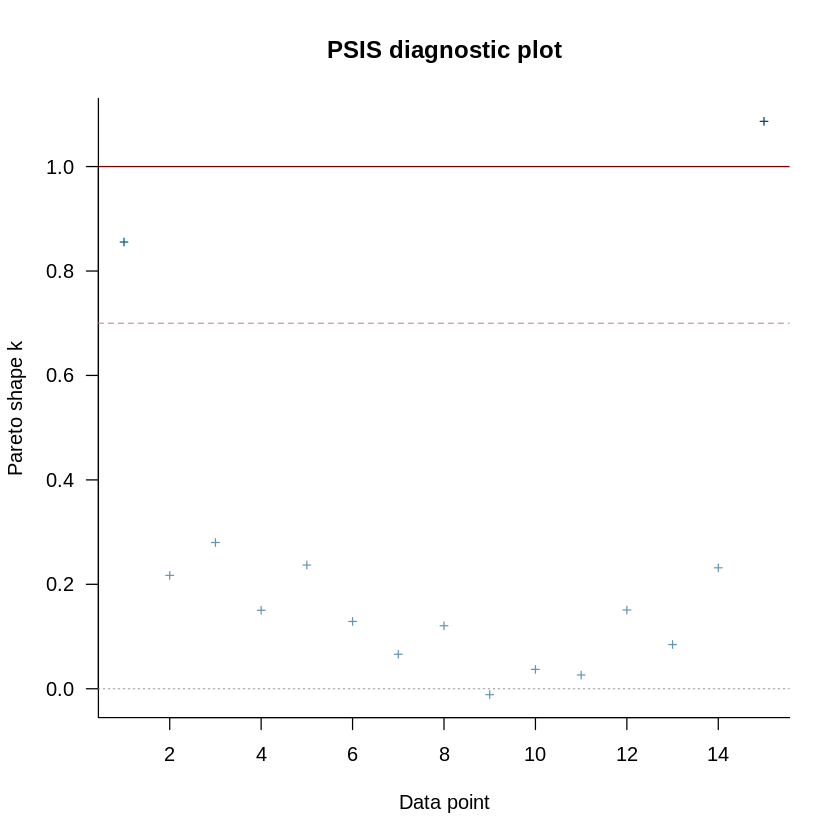

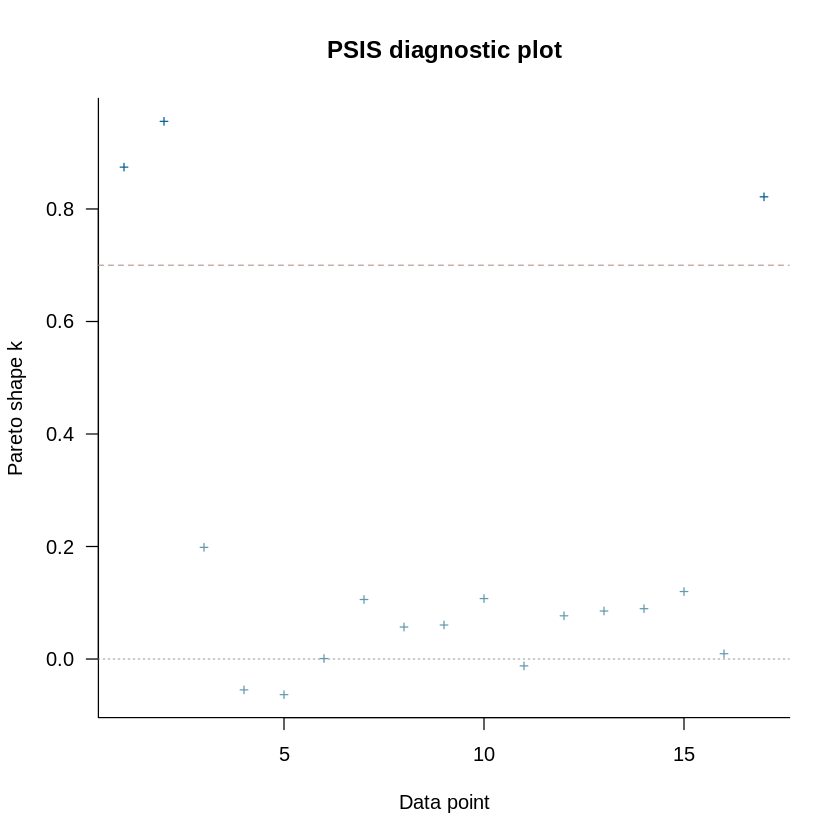

In [30]:
# Verify LOO diagnostic
loo_metropolis_vft <- loo(extract_log_lik(fit_vft_metropolis))
plot(loo_metropolis_vft)

loo_kswap_vft <- loo(extract_log_lik(fit_vft_kswap))
plot(loo_kswap_vft)

Only a few data points exhibited a Pareto $k$ diagnostic value slightly above the 0.7 threshold. This minor diagnostic alert is a consequence of the extreme sensitivity of the VFT model near the glass transition temperature ($T_g$). Since the remaining observations are well-behaved and the model parameters converged successfully, this isolated point is considered an influential outlier rather than an indication of model misspecification. The physical nature of the VFT equation, which diverges as $T \to T_0$, inherently makes observations at the lowest experimental temperatures highly influential on the posterior estimates.

## Posterior Predictive Checks (PPC)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the bayesplot package.
  Please report the issue at <https://github.com/stan-dev/bayesplot/issues/>.”


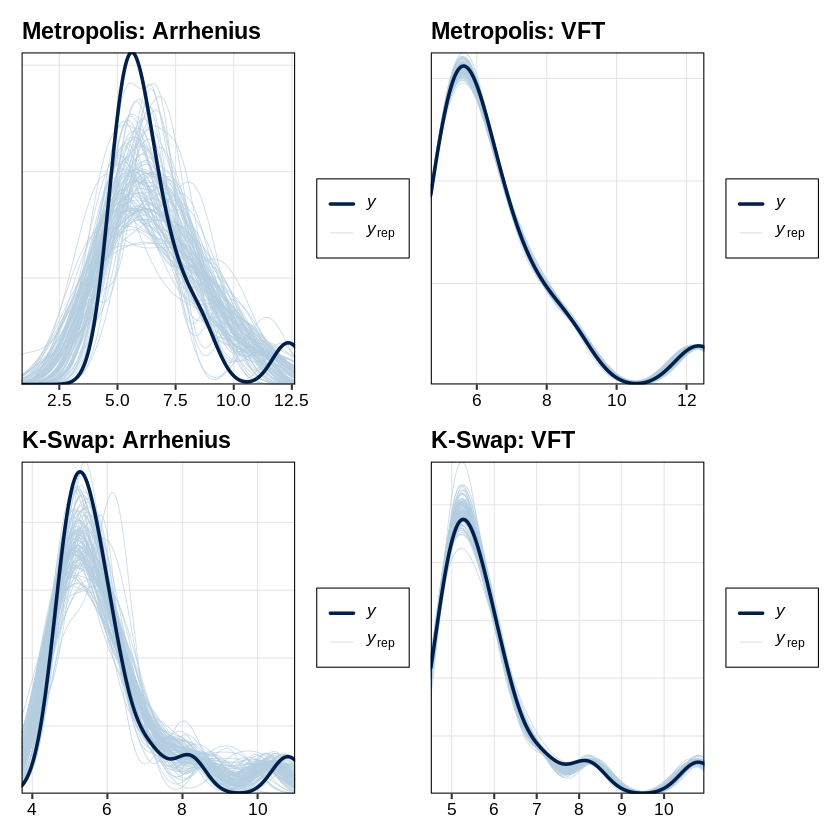

POSTERIOR PREDICTIVE CHECK METRICS
--- Metropolis (Arrhenius) ---
  Empirical 95% Predictive Coverage: 100.00%
  Bayesian p-value (Residual SD):    0.6335

--- Metropolis (VFT) ---
  Empirical 95% Predictive Coverage: 100.00%
  Bayesian p-value (Residual SD):    0.9005

--- K-Swap (Arrhenius) ---
  Empirical 95% Predictive Coverage: 100.00%
  Bayesian p-value (Residual SD):    0.6318

--- K-Swap (VFT) ---
  Empirical 95% Predictive Coverage: 100.00%
  Bayesian p-value (Residual SD):    0.6985



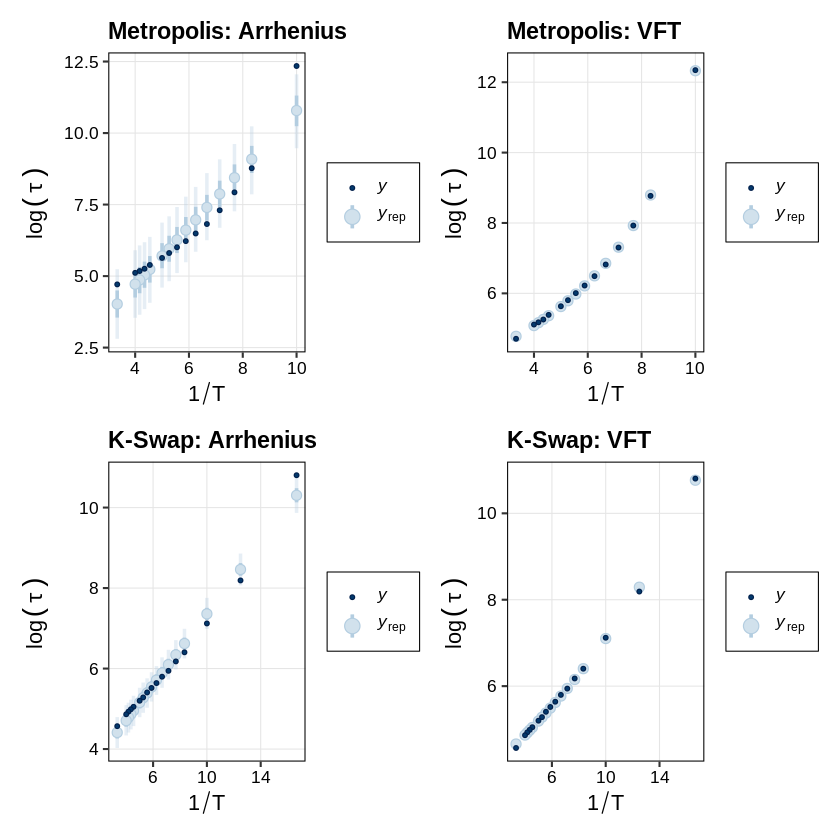

In [31]:
y_obs_met <- log(df_metropolis$relaxation_time)
y_obs_ksw <- log(df_kswap$relaxation_time)
x_obs_met <- 1 / df_metropolis$temperature
x_obs_ksw <- 1 / df_kswap$temperature

y_rep_arr_met <- extract(fit_arr_metropolis)$y_rep
y_rep_vft_met <- extract(fit_vft_metropolis)$y_rep
y_rep_arr_ksw <- extract(fit_arr_kswap)$y_rep
y_rep_vft_ksw <- extract(fit_vft_kswap)$y_rep

# Plot 1: Density Overlays
p1 <- ppc_dens_overlay(y = y_obs_met, yrep = y_rep_arr_met[1:100, ]) + labs(title = "Metropolis: Arrhenius")
p2 <- ppc_dens_overlay(y = y_obs_met, yrep = y_rep_vft_met[1:100, ]) + labs(title = "Metropolis: VFT")
p3 <- ppc_dens_overlay(y = y_obs_ksw, yrep = y_rep_arr_ksw[1:100, ]) + labs(title = "K-Swap: Arrhenius")
p4 <- ppc_dens_overlay(y = y_obs_ksw, yrep = y_rep_vft_ksw[1:100, ]) + labs(title = "K-Swap: VFT")
print((p1 + p2) / (p3 + p4))

# Plot 2: Pointwise Intervals
p5 <- ppc_intervals(y = y_obs_met, yrep = y_rep_arr_met, x = x_obs_met) + labs(x = expression(1/T), y = expression(log(tau)), title = "Metropolis: Arrhenius")
p6 <- ppc_intervals(y = y_obs_met, yrep = y_rep_vft_met, x = x_obs_met) + labs(x = expression(1/T), y = expression(log(tau)), title = "Metropolis: VFT")
p7 <- ppc_intervals(y = y_obs_ksw, yrep = y_rep_arr_ksw, x = x_obs_ksw) + labs(x = expression(1/T), y = expression(log(tau)), title = "K-Swap: Arrhenius")
p8 <- ppc_intervals(y = y_obs_ksw, yrep = y_rep_vft_ksw, x = x_obs_ksw) + labs(x = expression(1/T), y = expression(log(tau)), title = "K-Swap: VFT")
print((p5 + p6) / (p7 + p8))

# Quantitative Metrics Function
compute_metrics <- function(y_obs, y_rep, fit, model_type, dataset_name, temp_vector) {
  lower <- apply(y_rep, 2, quantile, 0.025)
  upper <- apply(y_rep, 2, quantile, 0.975)
  coverage_95 <- mean(y_obs >= lower & y_obs <= upper)

  sum_fit <- summary(fit)$summary
  if (model_type == "Arrhenius") {
    mu_hat <- sum_fit["A", "mean"] + (sum_fit["E", "mean"] / temp_vector)
  } else {
    mu_hat <- sum_fit["A", "mean"] + (sum_fit["B", "mean"] / (temp_vector - sum_fit["T0", "mean"]))
  }

  T_obs <- sd(y_obs - mu_hat)
  T_rep <- apply(y_rep, 1, function(row) sd(row - mu_hat))
  p_bayes <- mean(T_rep >= T_obs)

  cat(sprintf("--- %s (%s) ---\n", dataset_name, model_type))
  cat(sprintf("  Empirical 95%% Predictive Coverage: %.2f%%\n", coverage_95 * 100))
  cat(sprintf("  Bayesian p-value (Residual SD):    %.4f\n\n", p_bayes))
}

cat("==================================================\n")
cat("POSTERIOR PREDICTIVE CHECK METRICS\n")
cat("==================================================\n")
compute_metrics(y_obs_met, y_rep_arr_met, fit_arr_metropolis, "Arrhenius", "Metropolis", df_metropolis$temperature)
compute_metrics(y_obs_met, y_rep_vft_met, fit_vft_metropolis, "VFT", "Metropolis", df_metropolis$temperature)
compute_metrics(y_obs_ksw, y_rep_arr_ksw, fit_arr_kswap, "Arrhenius", "K-Swap", df_kswap$temperature)
compute_metrics(y_obs_ksw, y_rep_vft_ksw, fit_vft_kswap, "VFT", "K-Swap", df_kswap$temperature)
cat("==================================================\n")

In [32]:
# Plot 1: Density Overlays
plot_densities <- (p1 + p2) / (p3 + p4)
# Salva o painel 2x2
ggsave("ppc_densities.png", plot = plot_densities, width = 10, height = 8, dpi = 300)

# Plot 2: Pointwise Intervals
plot_intervals <- (p5 + p6) / (p7 + p8)
# Salva o painel 2x2
ggsave("ppc_intervals.png", plot = plot_intervals, width = 10, height = 8, dpi = 300)

## Residues calculation

In [33]:
calc_res_arrhenius <- function(fit, df, model_name) {
  post <- summary(fit)$summary
  A <- post["A", "mean"]
  E <- post["E", "mean"]
  sig <- post["sigma_int", "mean"]

  # Arrhenius na escala log: log(tau) = A + B * (1/T)
  # Como seu X no gráfico é 1/T:
  mu <- A + E * (1/df$temperature)

  data.frame(x = 1/df$temperature, residue = (log(df$relaxation_time) - mu) / sig, Model = model_name)
}

calc_res_vft <- function(fit, df, model_name) {
  post <- summary(fit)$summary
  A <- post["A", "mean"]
  B <- post["B", "mean"]
  T0 <- post["T0", "mean"]
  sig <- post["sigma_int", "mean"]

  # VFT na escala log: log(tau) = A + B / (T - T0)
  mu <- A + B / (df$temperature - T0)

  data.frame(x = 1/df$temperature, residue = (log(df$relaxation_time) - mu) / sig, Model = model_name)
}


In [34]:
res_arr_met <- calc_res_arrhenius(fit_arr_metropolis, df_metropolis, "Arrhenius (Metropolis)")
res_vft_met <- calc_res_vft(fit_vft_metropolis, df_metropolis, "VFT (Metropolis)")
res_arr_ksw <- calc_res_arrhenius(fit_arr_kswap, df_kswap, "Arrhenius (K-Swap)")
res_vft_ksw <- calc_res_vft(fit_vft_kswap, df_kswap, "VFT (K-Swap)")

all_residues <- rbind(res_arr_met, res_vft_met, res_arr_ksw, res_vft_ksw)

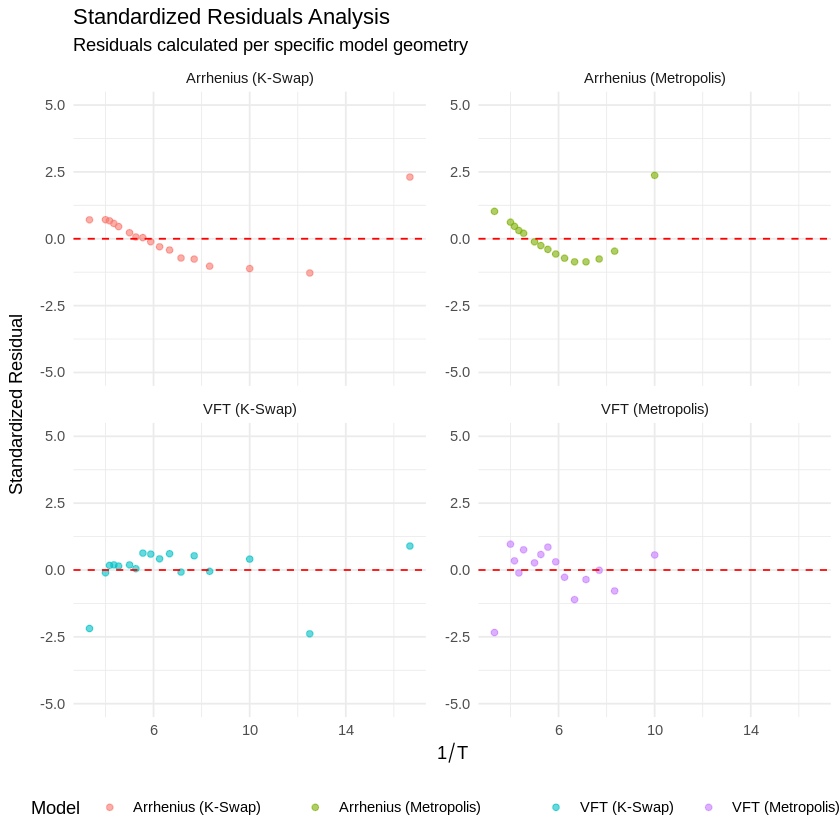

In [36]:


ggplot(all_residues, aes(x = x, y = residue, color = Model)) +
  geom_point(alpha = 0.6) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "red") +
  facet_wrap(~ Model, scales = "free_y") +
  coord_cartesian(ylim = c(-5, 5)) +
  labs(title = "Standardized Residuals Analysis",
       subtitle = "Residuals calculated per specific model geometry",
       x = expression(1/T),
       y = "Standardized Residual") +
  theme_minimal() +
  theme(legend.position = "bottom")
ggsave("residuals.png", width = 8, height = 6, dpi = 300)

## Posterior mean

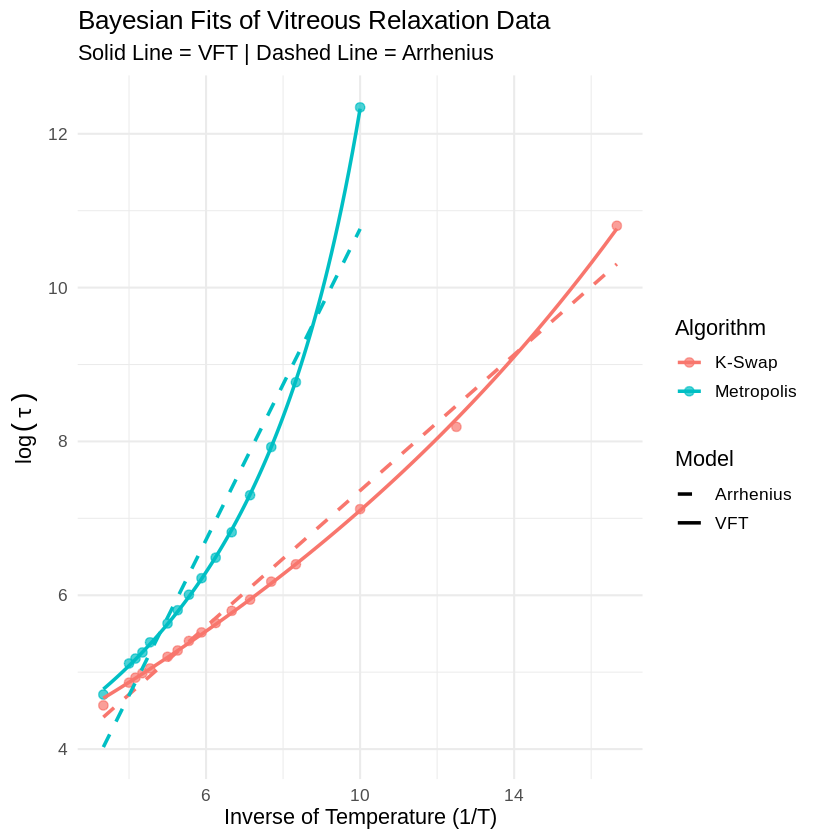

In [37]:
# Generates the posterior mean curve (Updated for A, B, T0 parameters)
generate_curve <- function(fit, df, model, algorithm, n_grid = 200) {
  pm <- summary(fit)$summary[, "mean"]
  temp_grid <- seq(min(df$temperature), max(df$temperature), length.out = n_grid)

  y_grid <- if (model == "Arrhenius") {
    pm["A"] + pm["E"] * (1 / temp_grid)
  } else {
    pm["A"] + pm["B"] / (temp_grid - pm["T0"])
  }

  data.frame(
    temperature = temp_grid,
    x = 1 / temp_grid,
    y = y_grid,
    Model = model,
    Algorithm = algorithm
  )
}

curve_arrh_metro  <- generate_curve(fit_arr_metropolis, df_metropolis, "Arrhenius", "Metropolis")
curve_vft_metro   <- generate_curve(fit_vft_metropolis,  df_metropolis, "VFT",       "Metropolis")
curve_arrh_kswap  <- generate_curve(fit_arr_kswap,       df_kswap,      "Arrhenius", "K-Swap")
curve_vft_kswap   <- generate_curve(fit_vft_kswap,       df_kswap,      "VFT",       "K-Swap")

df_curves <- rbind(curve_arrh_metro, curve_vft_metro, curve_arrh_kswap, curve_vft_kswap)


df_metropolis$Algorithm <- "Metropolis"
df_kswap$Algorithm      <- "K-Swap"
df_points <- rbind(
  df_metropolis[, c("x", "y", "Algorithm")],
  df_kswap[, c("x", "y", "Algorithm")]
)


ggplot() +
  geom_point(data = df_points,
             aes(x = x, y = y, color = Algorithm),
             size = 2.2, alpha = 0.7) +
  geom_line(data = df_curves,
            aes(x = x, y = y, color = Algorithm, linetype = Model),
            linewidth = 1) +
  scale_linetype_manual(values = c("Arrhenius" = "dashed", "VFT" = "solid")) +
  labs(
    x = "Inverse of Temperature (1/T)",
    y = expression(log(tau)),
    title = "Bayesian Fits of Vitreous Relaxation Data",
    subtitle = "Solid Line = VFT | Dashed Line = Arrhenius",
    color = "Algorithm",
    linetype = "Model"
  ) +
  theme_minimal(base_size = 13)
ggsave("postmean.png", width = 8, height = 6, dpi = 300)

## Predictive bands

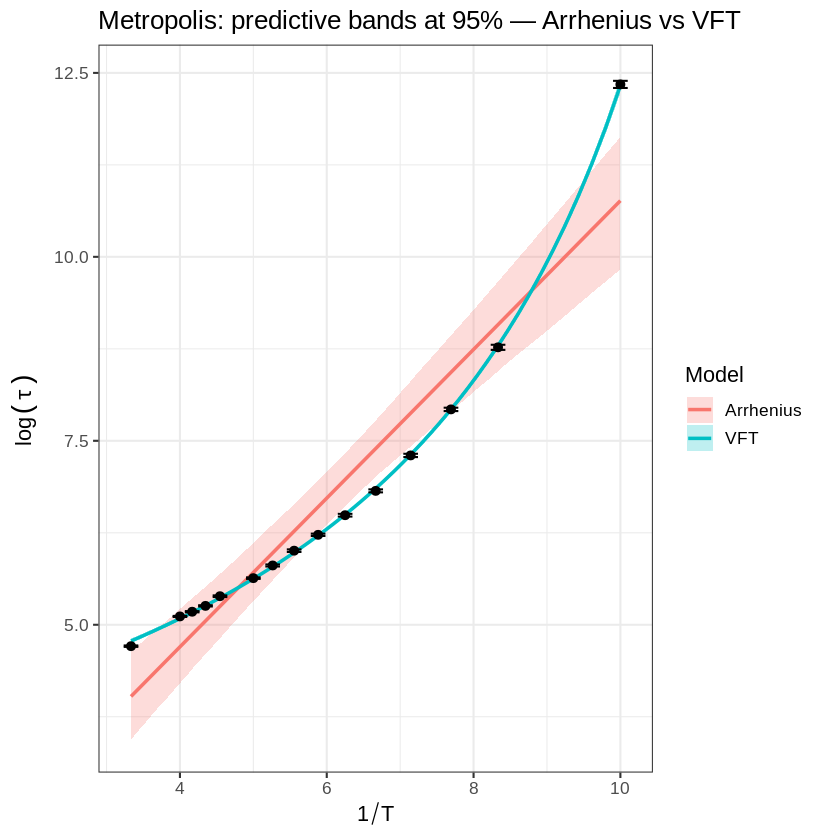

In [38]:
generate_band <- function(fit, df, model, n_grid = 100) {
  ext <- extract(fit)
  temp_grid <- seq(min(df$temperature), max(df$temperature), length.out = n_grid)
  matrix_pred <- matrix(NA, nrow = length(ext$A), ncol = n_grid)

  for (j in seq_along(temp_grid)) {
    if (model == "Arrhenius") {
      matrix_pred[, j] <- ext$A + ext$E * (1 / temp_grid[j])
    } else {
      matrix_pred[, j] <- ext$A + ext$B / (temp_grid[j] - ext$T0)
    }
  }

  data.frame(
    temperature = temp_grid,
    x = 1 / temp_grid,
    y_media = apply(matrix_pred, 2, mean),
    y_inf   = apply(matrix_pred, 2, quantile, probs = 0.025),
    y_sup   = apply(matrix_pred, 2, quantile, probs = 0.975),
    Model = model
  )
}

band_arrh_metro <- generate_band(fit_arr_metropolis, df_metropolis, "Arrhenius")
band_vft_metro  <- generate_band(fit_vft_metropolis,  df_metropolis, "VFT")
bands_metro <- rbind(band_arrh_metro, band_vft_metro)

ggplot() +
  geom_ribbon(data = bands_metro, aes(x = x, ymin = y_inf, ymax = y_sup, fill = Model), alpha = 0.25) +
  geom_line(data = bands_metro, aes(x = x, y = y_media, color = Model), linewidth = 1) +
  geom_point(data = df_metropolis, aes(x = x, y = y), color = "black", size = 2) +
  geom_errorbar(data = df_metropolis, aes(x = x, ymin = y - sigma_y, ymax = y + sigma_y), width = 0.2) +
  labs(title = "Metropolis: predictive bands at 95% — Arrhenius vs VFT",
       x = expression(1/T), y = expression(log(tau))) +
  theme_bw(base_size = 13)
ggsave("predbands.png", width = 8, height = 6, dpi = 300)

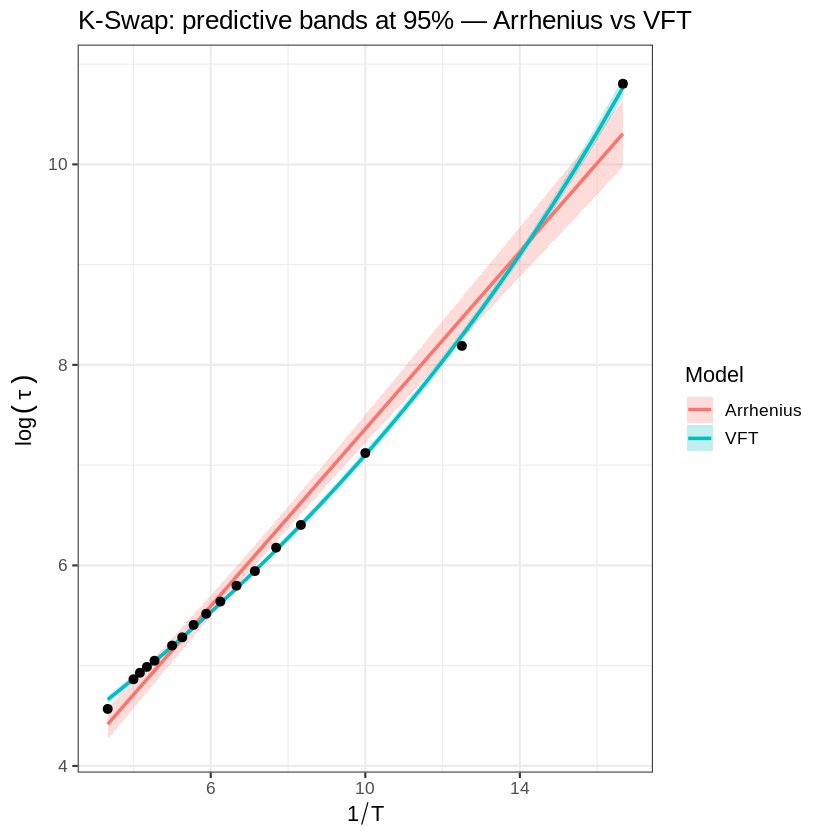

In [39]:
band_arrh_kswap <- generate_band(fit_arr_kswap, df_kswap, "Arrhenius")
band_vft_kswap  <- generate_band(fit_vft_kswap,  df_kswap, "VFT")
bands_kswap <- rbind(band_arrh_kswap, band_vft_kswap)

ggplot() +
  geom_ribbon(data = bands_kswap, aes(x = x, ymin = y_inf, ymax = y_sup, fill = Model), alpha = 0.25) +
  geom_line(data = bands_kswap, aes(x = x, y = y_media, color = Model), linewidth = 1) +
  geom_point(data = df_kswap, aes(x = x, y = y), color = "black", size = 2) +
  geom_errorbar(data = df_kswap, aes(x = x, ymin = y - sigma_y, ymax = y + sigma_y), width = 0.2) +
  labs(title = "K-Swap: predictive bands at 95% — Arrhenius vs VFT",
       x = expression(1/T), y = expression(log(tau))) +
  theme_bw(base_size = 13)
ggsave("predbandsks.png", width = 8, height = 6, dpi = 300)

## Prediction on T_new = 0.8min_i T_i with pole checking


=== Metropolis (VFT) ===
T_min = 0.1  | T_new = 0.08 
Proportion of draws with T0 > T_new (unstable extrapolation): 0 
Median of log(tau_pred): 31.71396 
IC 95% of log(tau_pred): [ 29.33067 , 34.93415 ]

=== kSwap (VFT) ===
T_min = 0.06  | T_new = 0.048 
Proportion of draws with T0 > T_new (unstable extrapolation): 0 
Median of log(tau_pred): 14.15848 
IC 95% of log(tau_pred): [ 13.8125 , 14.54475 ]


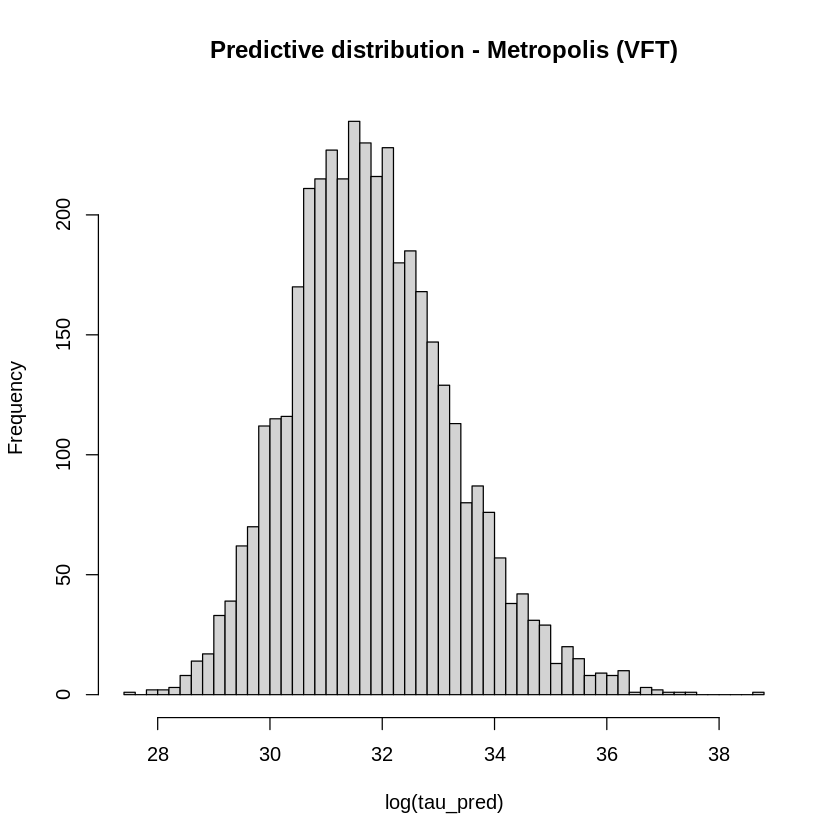

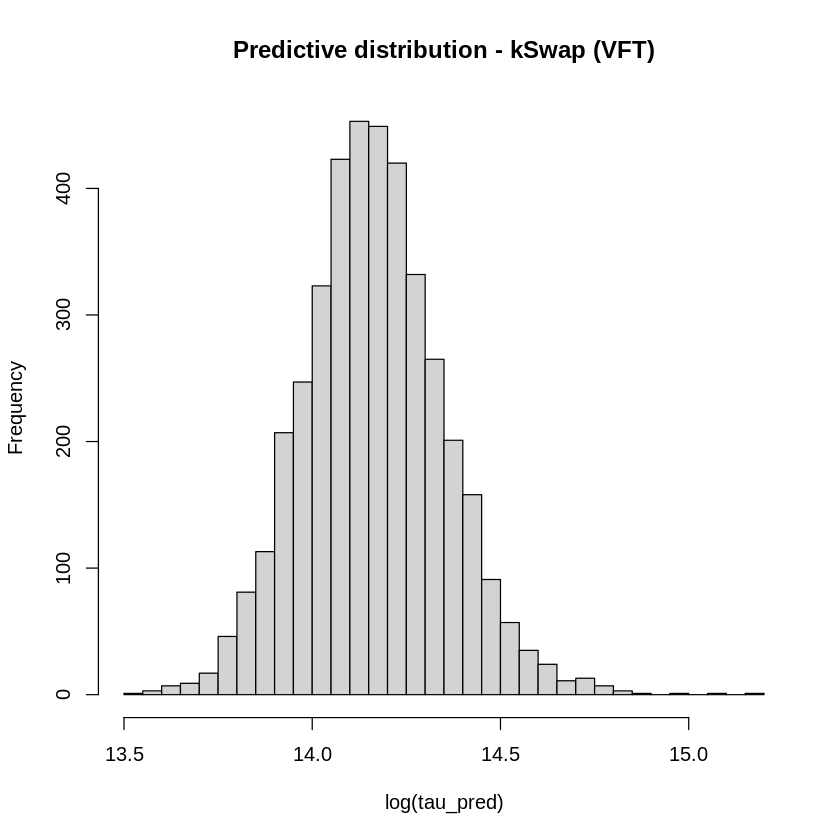

In [40]:
predict_vft <- function(fit, df, name) {
  ext <- extract(fit)
  T_min <- min(df$temperature)
  T_new <- 0.8 * T_min

  #  Fraction of draws where T0 > T_new -> physically inconsistent extrapolation
  frac_problem <- mean(ext$T0 > T_new)

  log_tau_pred <- ext$A + ext$B / (T_new - ext$T0)

  cat("\n===", name, "===\n")
  cat("T_min =", T_min, " | T_new =", T_new, "\n")
  cat("Proportion of draws with T0 > T_new (unstable extrapolation):", frac_problem, "\n")
  cat("Median of log(tau_pred):", median(log_tau_pred), "\n")
  cat("IC 95% of log(tau_pred): [",
      quantile(log_tau_pred, 0.025), ",", quantile(log_tau_pred, 0.975), "]\n")

  hist(log_tau_pred, breaks = 60, main = paste("Predictive distribution -", name),
       xlab = "log(tau_pred)")

  invisible(log_tau_pred)
}

log_tau_pred_metro <- predict_vft(fit_vft_metropolis, df_metropolis, "Metropolis (VFT)")
log_tau_pred_kswap <- predict_vft(fit_vft_kswap, df_kswap, "kSwap (VFT)")



=== Metropolis (Arrhenius) ===
T_min = 0.1  | T_new = 0.08 
Median of log(tau_pred): 13.3007 
IC 95% of log(tau_pred): [ 11.89862 , 14.59776 ]

=== KSwap (Arrhenius) ===
T_min = 0.06  | T_new = 0.048 
Median of log(tau_pred): 12.15036 
IC 95% of log(tau_pred): [ 11.68232 , 12.59933 ]


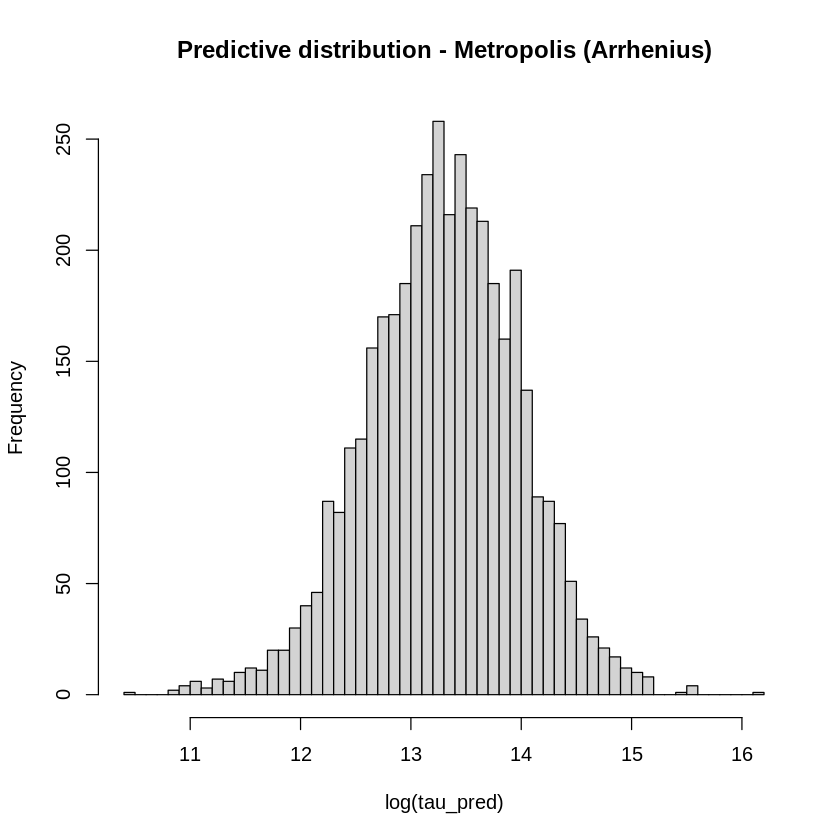

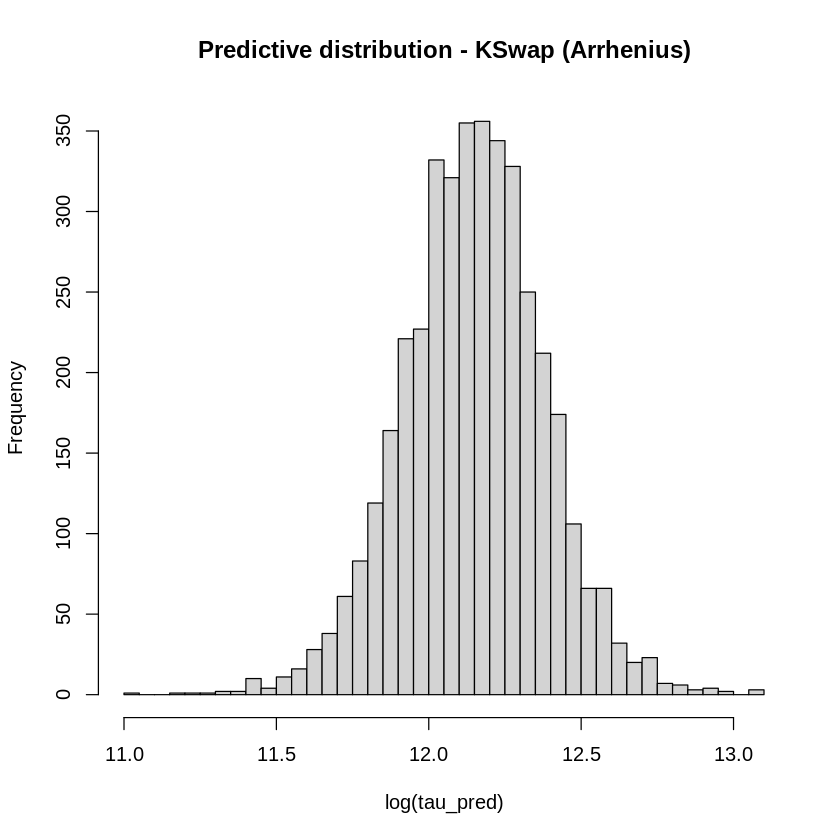

In [41]:
predict_arrhenius <- function(fit, df, name) {
  ext <- extract(fit)


  T_min <- min(df$temperature)
  T_new <- 0.8 * T_min

  x_new <- 1 / T_new
  log_tau_pred <- ext$A + ext$E * x_new

  cat("\n===", name, "===\n")
  cat("T_min =", T_min, " | T_new =", T_new, "\n")
  cat("Median of log(tau_pred):", median(log_tau_pred, na.rm = TRUE), "\n")
  cat("IC 95% of log(tau_pred): [",
      quantile(log_tau_pred, 0.025, na.rm = TRUE), ",",
      quantile(log_tau_pred, 0.975, na.rm = TRUE), "]\n")

  hist(log_tau_pred, breaks = 60, main = paste("Predictive distribution -", name),
       xlab = "log(tau_pred)")

  invisible(log_tau_pred)
}



log_tau_pred_arrh_metro <- predict_arrhenius(fit_arr_metropolis, df_metropolis, "Metropolis (Arrhenius)")
log_tau_pred_arrh_ks <- predict_arrhenius(fit_arr_kswap, df_kswap, "KSwap (Arrhenius)")

##  Prior predictive checks

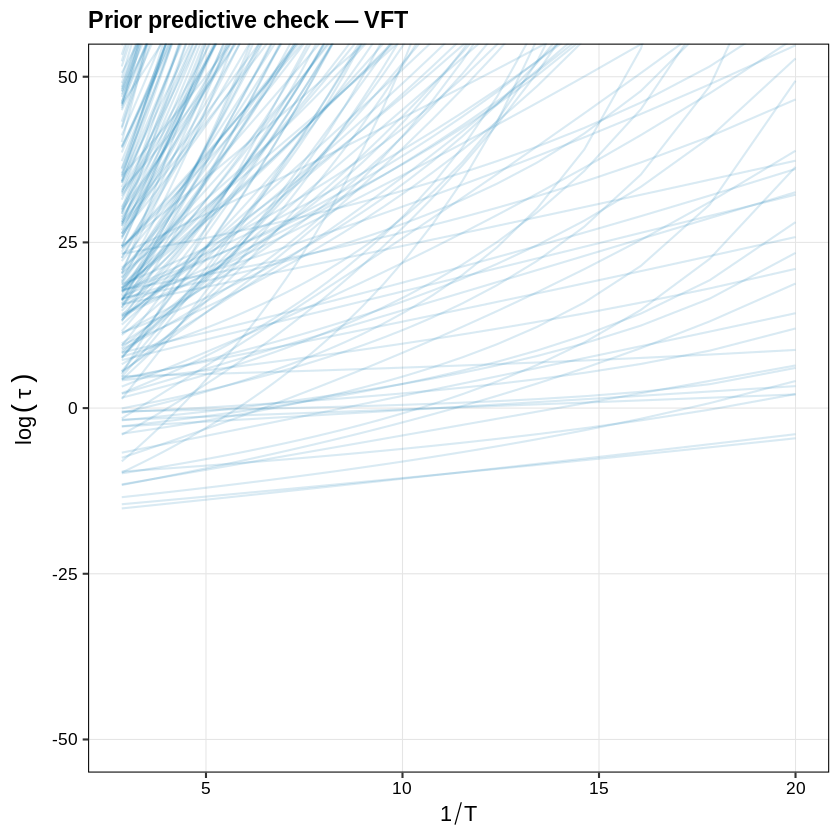

In [42]:
set.seed(123)
n_sim <- 200
T_grid <- seq(0.05, 0.35, length.out = 50)

# Sample directly from the priors (without running Stan)
A_prior   <- rnorm(n_sim, 0, 10)
B_prior   <- abs(rnorm(n_sim, 0, 10))
T0_prior  <- runif(n_sim, 0, 0.05)  # ex: min_temp

curves_prior <- expand.grid(sim = 1:n_sim, T = T_grid)
curves_prior$y <- with(curves_prior,
                        A_prior[sim] + B_prior[sim] / (T - T0_prior[sim]))

ggplot(curves_prior, aes(x = 1/T, y = y, group = sim)) +
  geom_line(alpha = 0.15, color = "#0072B2") +
  coord_cartesian(ylim = c(-50, 50)) +
  labs(x = expression(1/T), y = expression(log(tau)),
       title = "Prior predictive check — VFT")
ggsave("ppredc.png", width = 8, height = 6, dpi = 300)

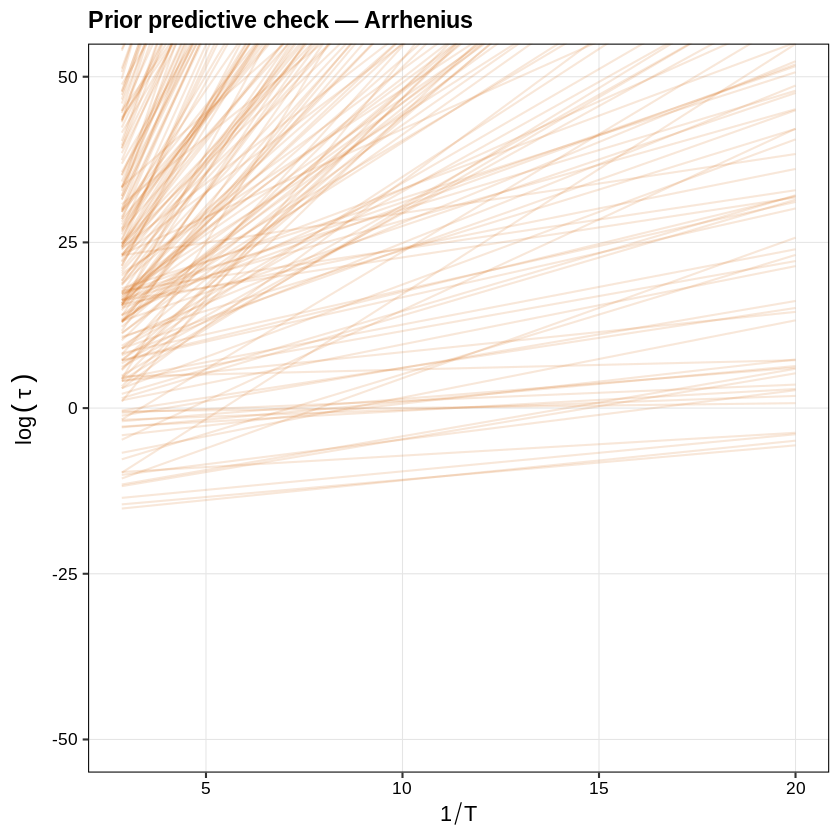

In [44]:
set.seed(123)
n_sim <- 200
T_grid <- seq(0.05, 0.35, length.out = 50)

# Arrhenius's Prior Draw (No T0)
A_prior_arr   <- rnorm(n_sim, 0, 10)
E_prior_arr   <- abs(rnorm(n_sim, 0, 10))

curves_prior_arr <- expand.grid(sim = 1:n_sim, T = T_grid)
curves_prior_arr$y <- with(curves_prior_arr,
                           A_prior_arr[sim] + E_prior_arr[sim] / T)

ggplot(curves_prior_arr, aes(x = 1/T, y = y, group = sim)) +
  geom_line(alpha = 0.15, color = "#D55E00") +
  coord_cartesian(ylim = c(-50, 50)) +
  labs(x = expression(1/T), y = expression(log(tau)),
       title = "Prior predictive check — Arrhenius")

ggsave("ppredcar.png", width = 8, height = 6, dpi = 300)

## Effective activation energy

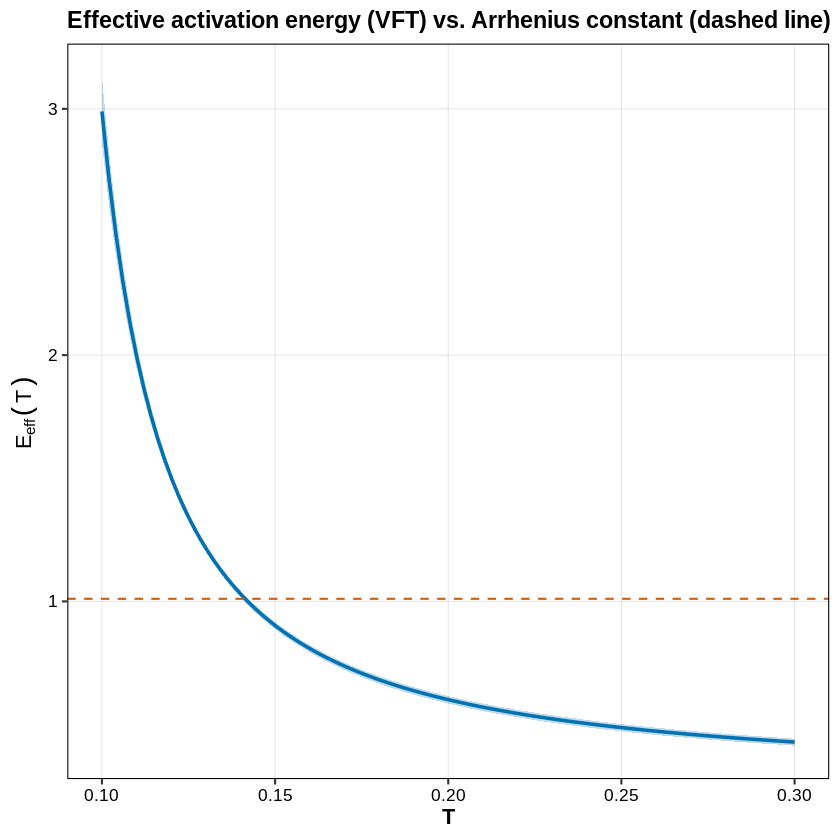

In [47]:
ext_vft <- extract(fit_vft_metropolis)
T_grid <- seq(min(df_metropolis$temperature), max(df_metropolis$temperature), length.out = 100)

E_eff_matrix <- matrix(NA, nrow = length(ext_vft$A), ncol = length(T_grid))
for (j in seq_along(T_grid)) {
  E_eff_matrix[, j] <- ext_vft$B * T_grid[j]^2 / (T_grid[j] - ext_vft$T0)^2
}

E_eff_df <- data.frame(
  T = T_grid,
  mean = apply(E_eff_matrix, 2, mean),
  inf = apply(E_eff_matrix, 2, quantile, 0.025),
  sup = apply(E_eff_matrix, 2, quantile, 0.975)
)

ggplot(E_eff_df, aes(x = T, y = mean)) +
  geom_ribbon(aes(ymin = inf, ymax = sup), fill = "#0072B2", alpha = 0.25) +
  geom_line(color = "#0072B2", linewidth = 1) +
  geom_hline(yintercept = summary(fit_arr_metropolis)$summary["E", "mean"],
             linetype = "dashed", color = "#D55E00") +
  labs(x = "T", y = expression(E[eff](T)),
       title = "Effective activation energy (VFT) vs. Arrhenius constant (dashed line)")
  ggsave("eae.png", width = 8, height = 6, dpi = 300)

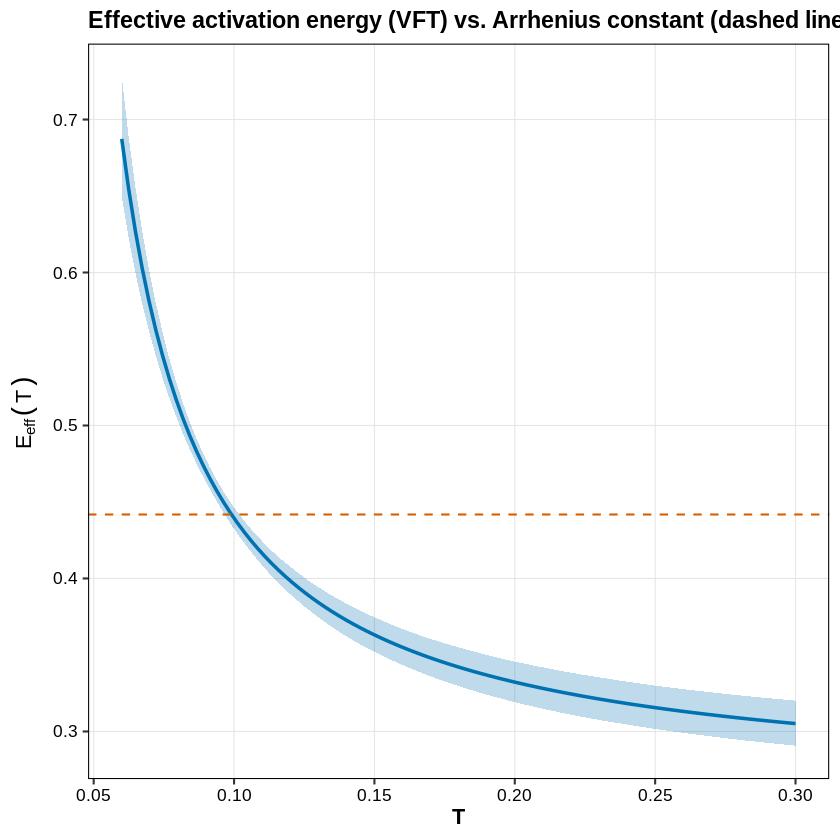

In [48]:
ext_vft <- extract(fit_vft_kswap)
T_grid <- seq(min(df_kswap$temperature), max(df_kswap$temperature), length.out = 100)

E_eff_matrix <- matrix(NA, nrow = length(ext_vft$A), ncol = length(T_grid))
for (j in seq_along(T_grid)) {
  E_eff_matrix[, j] <- ext_vft$B * T_grid[j]^2 / (T_grid[j] - ext_vft$T0)^2
}

E_eff_df <- data.frame(
  T = T_grid,
  mean = apply(E_eff_matrix, 2, mean),
  inf = apply(E_eff_matrix, 2, quantile, 0.025),
  sup = apply(E_eff_matrix, 2, quantile, 0.975)
)

ggplot(E_eff_df, aes(x = T, y = mean)) +
  geom_ribbon(aes(ymin = inf, ymax = sup), fill = "#0072B2", alpha = 0.25) +
  geom_line(color = "#0072B2", linewidth = 1) +
  geom_hline(yintercept = summary(fit_arr_kswap)$summary["E", "mean"],
             linetype = "dashed", color = "#D55E00") +
  labs(x = "T", y = expression(E[eff](T)),
       title = "Effective activation energy (VFT) vs. Arrhenius constant (dashed line)")
       ggsave("eaeswap.png", width = 8, height = 6, dpi = 300)